# TP4 y TP5 — Modelos Estacionales y de Volatilidad: Petróleo WTI

**Universidad Católica Argentina — Licenciatura en Ciencia de Datos**  
**Análisis y Predicción en Series de Tiempo**

Continuación de los TP1–TP3. Este notebook cubre:

**TP4 — Modelos Estacionales:**
1. Análisis de estacionalidad en el WTI
2. SAR, SMA, SARMA puros
3. SARIMA$(p,d,q)(P,D,Q)_s$ completo
4. Modelo REGARMA
5. Regresión estacional armónica
6. Diagnóstico y predicción de cada modelo

**TP5 — Modelos de Volatilidad:**
1. Retomada del GARCH(1,1) del TP3
2. ARCH(p)
3. GARCH(p,q)
4. EGARCH
5. TGARCH / GJR-GARCH
6. Cuadro comparativo y conclusiones

---
## 0. Configuración del Entorno

In [1]:
import os
from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from arch import arch_model
from scipy import stats
import pmdarima as pm
from dotenv import load_dotenv
import os


FRED_API_KEY = 'e91e10ae028965f4d921ed9082cae691'
fred = Fred(api_key=FRED_API_KEY)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [2]:
warnings.filterwarnings('ignore')

---
## 1. Carga y Preprocesamiento (idéntico a TP1–TP3)

In [3]:
load_dotenv()
FRED_API_KEY = 'e91e10ae028965f4d921ed9082cae691'
fred = Fred(api_key=FRED_API_KEY)

wti_raw = fred.get_series('DCOILWTICO', observation_start='1986-01-01')
df = pd.DataFrame(wti_raw, columns=['Close'])
df['Close'] = df['Close'].ffill().bfill()
df.loc['2020-04-20', 'Close'] = np.nan
df['Close'] = df['Close'].interpolate(method='linear')

# Serie de retornos logarítmicos (usada en TP2 y TP3)
serie = np.log(df['Close']).diff().dropna()
serie.name = 'log_ret_WTI'

# Precio original (para SARIMA sobre precio)
precio = df['Close']

print(f'Observaciones: {len(serie)}')
print(f'Período      : {serie.index[0].date()} → {serie.index[-1].date()}')

Observaciones: 10547
Período      : 1986-01-03 → 2026-06-08


---
# TP4 — MODELOS ESTACIONALES

---
## 2. ¿Tiene el WTI componente estacional?

### 2.1 Justificación del contexto

Los **retornos logarítmicos** del WTI (serie de trabajo del TP2/TP3) son estacionarios
y con escasa memoria lineal — como verificamos con KPSS. Para buscar estacionalidad
tiene más sentido trabajar sobre el **precio mensual**, que es donde típicamente
emergen patrones estacionales en commodities energéticos (demanda invernal,
ciclos de producción OPEC, etc.).

Remuestreamos el precio a frecuencia mensual y analizamos si hay estacionalidad.

Precio mensual: 486 obs. (1986-01-01 → 2026-06-01)


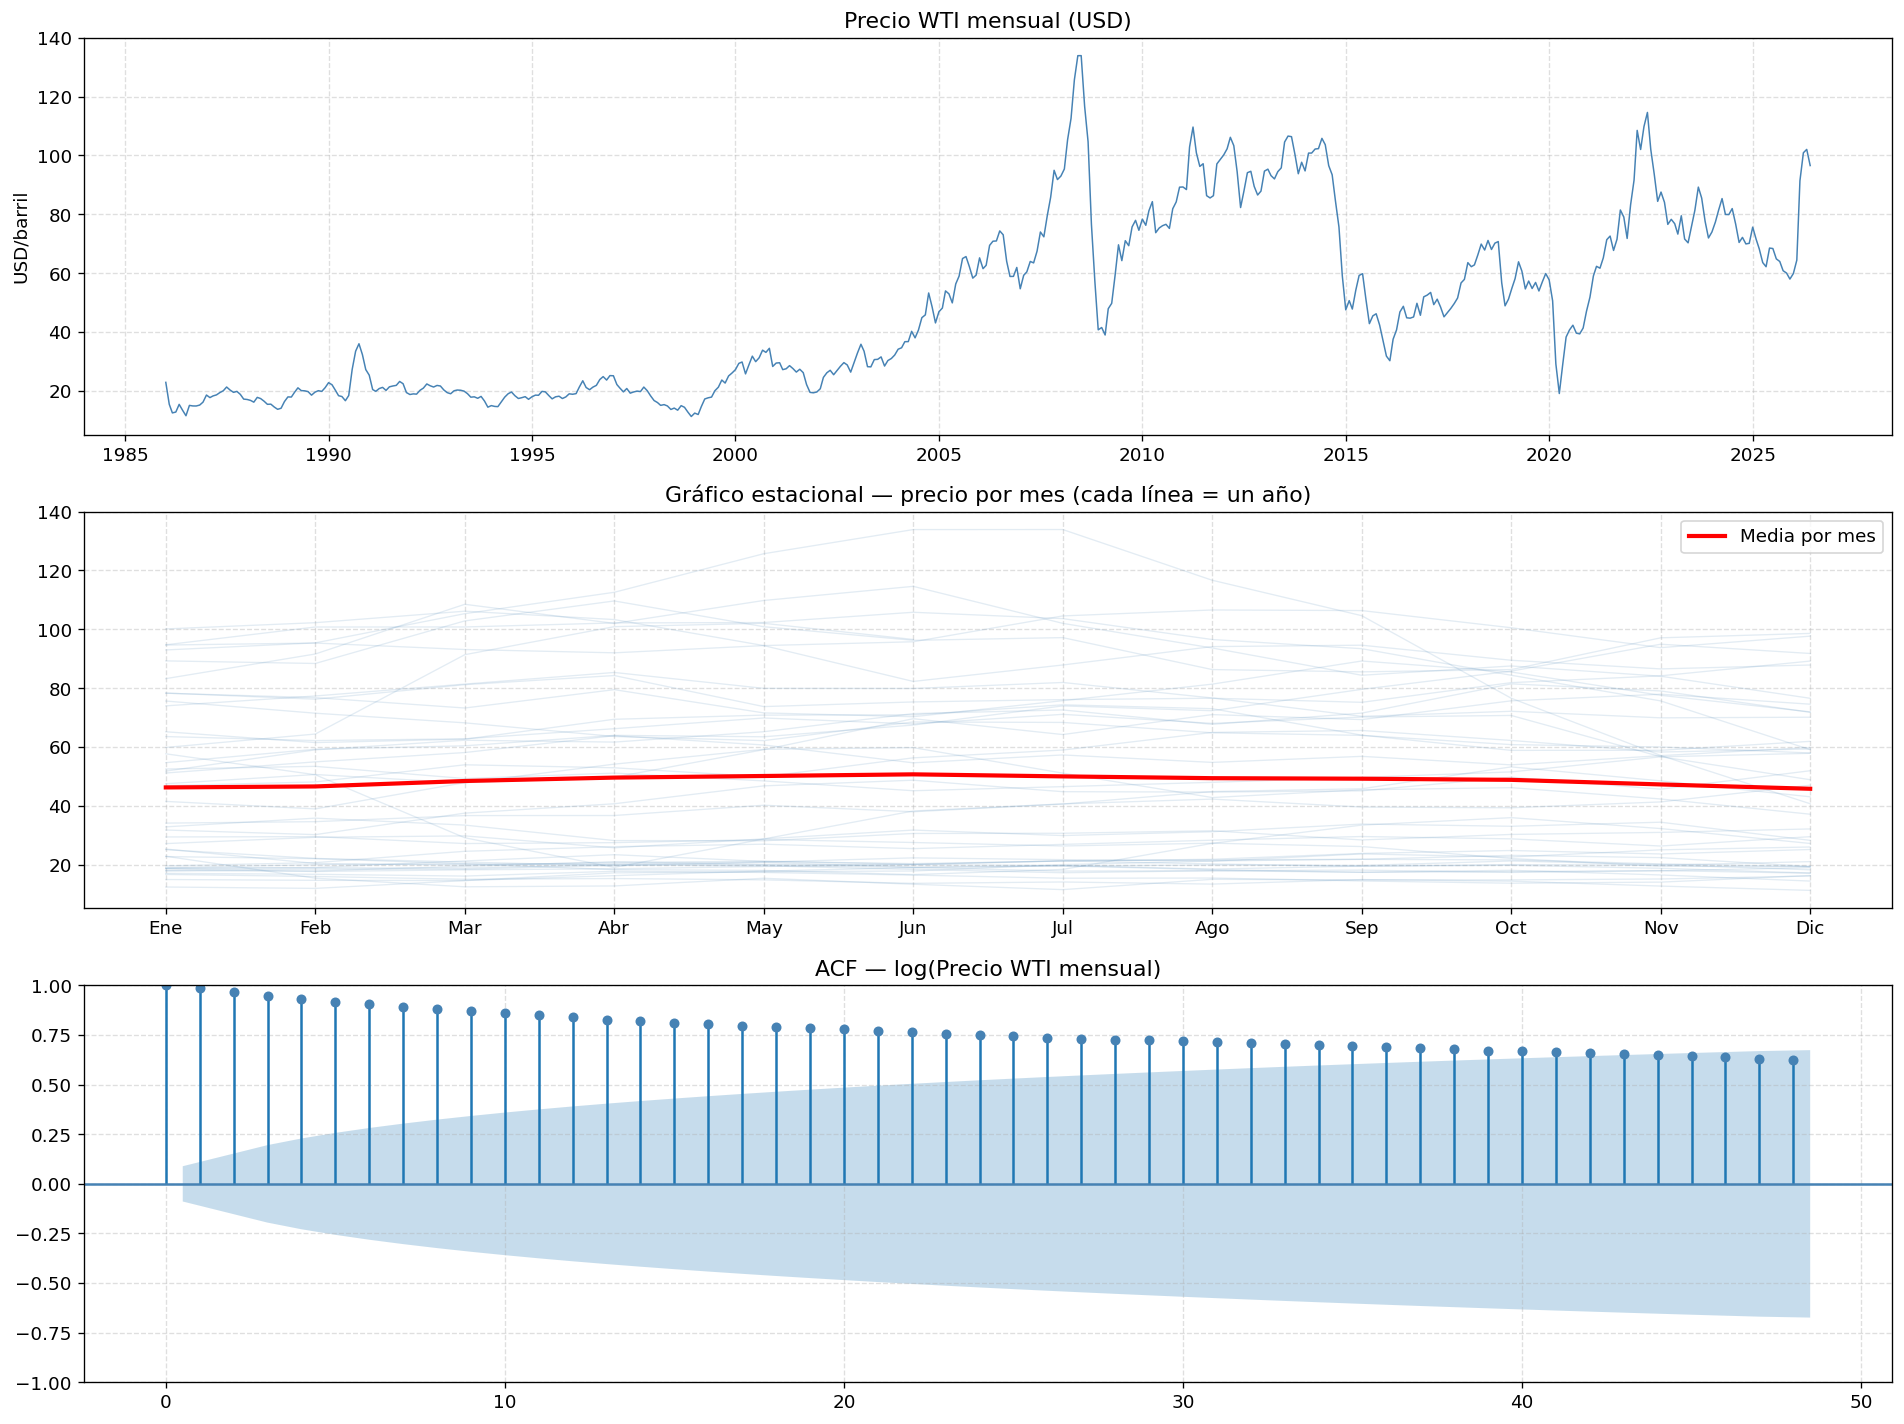

In [4]:
# Precio mensual (media mensual)
precio_mensual = precio.resample('MS').mean().dropna()
log_precio_mensual = np.log(precio_mensual)

print(f'Precio mensual: {len(precio_mensual)} obs. '
      f'({precio_mensual.index[0].date()} → {precio_mensual.index[-1].date()})')

# --- Gráfico exploratorio ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(precio_mensual, color='steelblue', linewidth=0.9)
axes[0].set_title('Precio WTI mensual (USD)')
axes[0].set_ylabel('USD/barril')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Gráfico estacional por mes
precio_mensual_df = precio_mensual.to_frame('precio')
precio_mensual_df['mes'] = precio_mensual_df.index.month
precio_mensual_df['año'] = precio_mensual_df.index.year
for año in precio_mensual_df['año'].unique():
    subset = precio_mensual_df[precio_mensual_df['año'] == año]
    axes[1].plot(subset['mes'], subset['precio'],
                 color='steelblue', alpha=0.15, linewidth=0.8)
media_mes = precio_mensual_df.groupby('mes')['precio'].mean()
axes[1].plot(media_mes.index, media_mes.values,
             color='red', linewidth=2.5, label='Media por mes')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].set_title('Gráfico estacional — precio por mes (cada línea = un año)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plot_acf(log_precio_mensual, lags=48, ax=axes[2],
         title='ACF — log(Precio WTI mensual)', alpha=0.05,
         color='steelblue')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Gráfico estacional — Precio mensual WTI

La línea roja (media por mes) es aproximadamente constante a lo largo de los 12 meses del año.

**Conclusión:** no hay estacionalidad determinista significativa en el precio mensual del WTI. El precio no varía sistemáticamente según el mes — es consistente con la naturaleza del mercado del petróleo, dominado por shocks geopolíticos y macroeconómicos que no siguen un calendario fijo.

### ACF del log(Precio mensual)
La ACF decae muy lentamente — recién los últimos rezagos entran en las bandas de confianza al 95%. Este comportamiento es la firma clásica de una serie no estacionaria con tendencia: el precio de hoy está altamente correlacionado con todos sus valores pasados porque la serie "se mueve junta" a lo largo del tiempo. No se observan picos en los lags 12, 24, 36 — ausencia de estructura estacional.

In [5]:
# --- Test KPSS sobre precio mensual y diferenciado ---
def kpss_test(serie, label):
    stat, pval, lags, crit = kpss(serie.dropna(), regression='c', nlags='auto')
    decision = 'No estacionaria' if pval < 0.05 else 'Estacionaria'
    print(f'{label:45s} stat={stat:.4f}  p={pval:.4f}  → {decision}')

print('─── Test KPSS ───')
kpss_test(log_precio_mensual,                        'log(Precio mensual)')
kpss_test(log_precio_mensual.diff(1).dropna(),       'Δ log(Precio mensual)  d=1')
kpss_test(log_precio_mensual.diff(12).dropna(),      'Δ₁₂ log(Precio mensual) D=1')
kpss_test(log_precio_mensual.diff(12).diff(1).dropna(), 'Δ Δ₁₂ log(Precio mensual) d=1,D=1')

─── Test KPSS ───
log(Precio mensual)                           stat=2.9436  p=0.0100  → No estacionaria
Δ log(Precio mensual)  d=1                    stat=0.0342  p=0.1000  → Estacionaria
Δ₁₂ log(Precio mensual) D=1                   stat=0.0701  p=0.1000  → Estacionaria
Δ Δ₁₂ log(Precio mensual) d=1,D=1             stat=0.0119  p=0.1000  → Estacionaria


### Test KPSS

**Conclusión:** con una sola diferenciación ordinaria ($d=1$) la serie ya es estacionaria. 

La no estacionaridad del precio mensual se debe principalmente a la **tendencia**, no a estacionalidad. Se adopta $d=1$, $D=1$ para el SARIMA a fin de capturar cualquier estructura estacional residual, aunque débil.

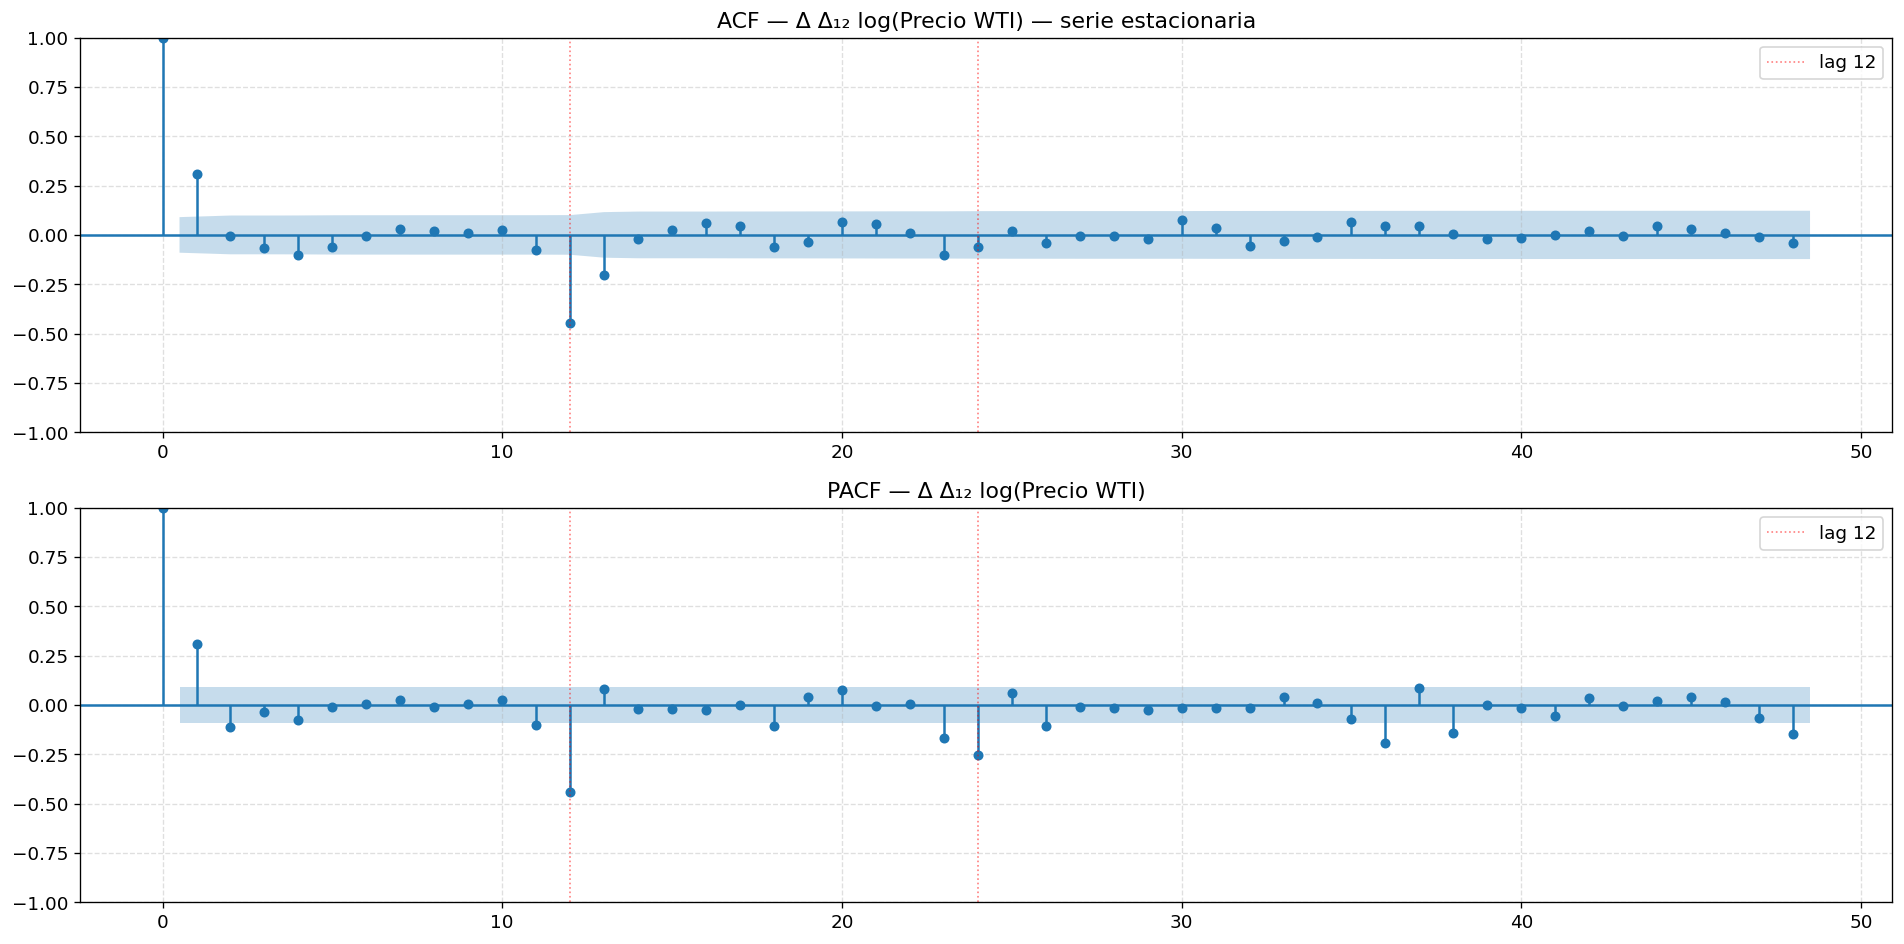

In [6]:
# --- ACF y PACF de la serie diferenciada (d=1, D=1, s=12) ---
serie_diff = log_precio_mensual.diff(12).diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(serie_diff, lags=48, ax=axes[0],
         title='ACF — Δ Δ₁₂ log(Precio WTI) — serie estacionaria', alpha=0.05)
plot_pacf(serie_diff, lags=48, method='ywm', ax=axes[1],
          title='PACF — Δ Δ₁₂ log(Precio WTI)', alpha=0.05)
for ax in axes:
    ax.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5, label='lag 12')
    ax.axvline(24, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()
plt.tight_layout()
plt.show()

### ACF y PACF — Δ Δ₁₂ log(Precio WTI)

**Parte ordinaria** (lags 1–11):
ACF y PACF muestran un único pico significativo en lag 1 (~0.30)
y se cortan abruptamente. Compatible con MA(1), AR(1) o ARMA(1,1).
Se recurrirá a criterios de información para discriminar.

**Parte estacional** (múltiplos de 12):
ACF presenta un pico negativo pronunciado en lag 12 (~-0.50) seguido
de un pico menor en lag 13, sin picos significativos en lag 24 ni 36.
PACF muestra picos en lag 12 (~-0.50) y lag 24 (~-0.28), decreciendo
en los lags estacionales. 

Según la tabla del apunte, cuando la ACF se
corta después del primer lag estacional y la PACF decrece en los lags
estacionales ks, el comportamiento es indicativo de **SMA(1)₁₂** → Q=1.

**Conclusión:** se ajustarán modelos SARIMA(p,1,q)(0,1,1)₁₂
con p,q ∈ {0,1}. Candidato principal: **SARIMA(0,1,1)(0,1,1)₁₂**.

---
## 3. Modelos SAR, SMA y SARMA Puros

ACF/PACF de la serie diferenciada:
- Parte ordinaria → pico en lag 1 → MA(1) o AR(1)
- Parte estacional → pico en lag 12, corte → SMA(1)₁₂

**Candidatos:** SARIMA(p,1,q)(P,1,1)₁₂ con p,q,P ∈ {0,1}

SAR(1)₁₂ ajustado.
SMA(1)₁₂ ajustado.
SARMA(1,1)₁₂ ajustado.
SARIMA(0,1,1)(0,1,1)₁₂ ajustado.
SARIMA(1,1,0)(0,1,1)₁₂ ajustado.
SARIMA(1,1,1)(0,1,1)₁₂ ajustado.
SARIMA(0,1,1)(1,1,1)₁₂ ajustado.
SARIMA(1,1,1)(1,1,1)₁₂ ajustado.

─── Cuadro comparativo unificado — modelos estacionales ───


,Tipo,LogLik,AIC,AICc,BIC,HQIC
Modelo,,,,,,
"SARIMA(0,1,1)(0,1,1)₁₂",SARIMA completo,453.59,-901.18,-901.14,-888.71,-896.25
"SARIMA(0,1,1)(1,1,1)₁₂",SARIMA completo,453.85,-899.70,-899.62,-883.06,-893.12
"SARIMA(1,1,0)(0,1,1)₁₂",SARIMA completo,450.58,-895.15,-895.10,-882.67,-890.22
"SARIMA(1,1,1)(0,1,1)₁₂",SARIMA completo,453.58,-899.16,-899.08,-882.52,-892.58
"SARIMA(1,1,1)(1,1,1)₁₂",SARIMA completo,453.78,-897.57,-897.44,-876.77,-889.35
SMA(1)₁₂,Estacional puro,429.39,-854.77,-854.75,-846.45,-851.48
"SARMA(1,1)₁₂",Estacional puro,429.86,-853.72,-853.67,-841.24,-848.78
SAR(1)₁₂,Estacional puro,343.30,-682.59,-682.57,-674.27,-679.30


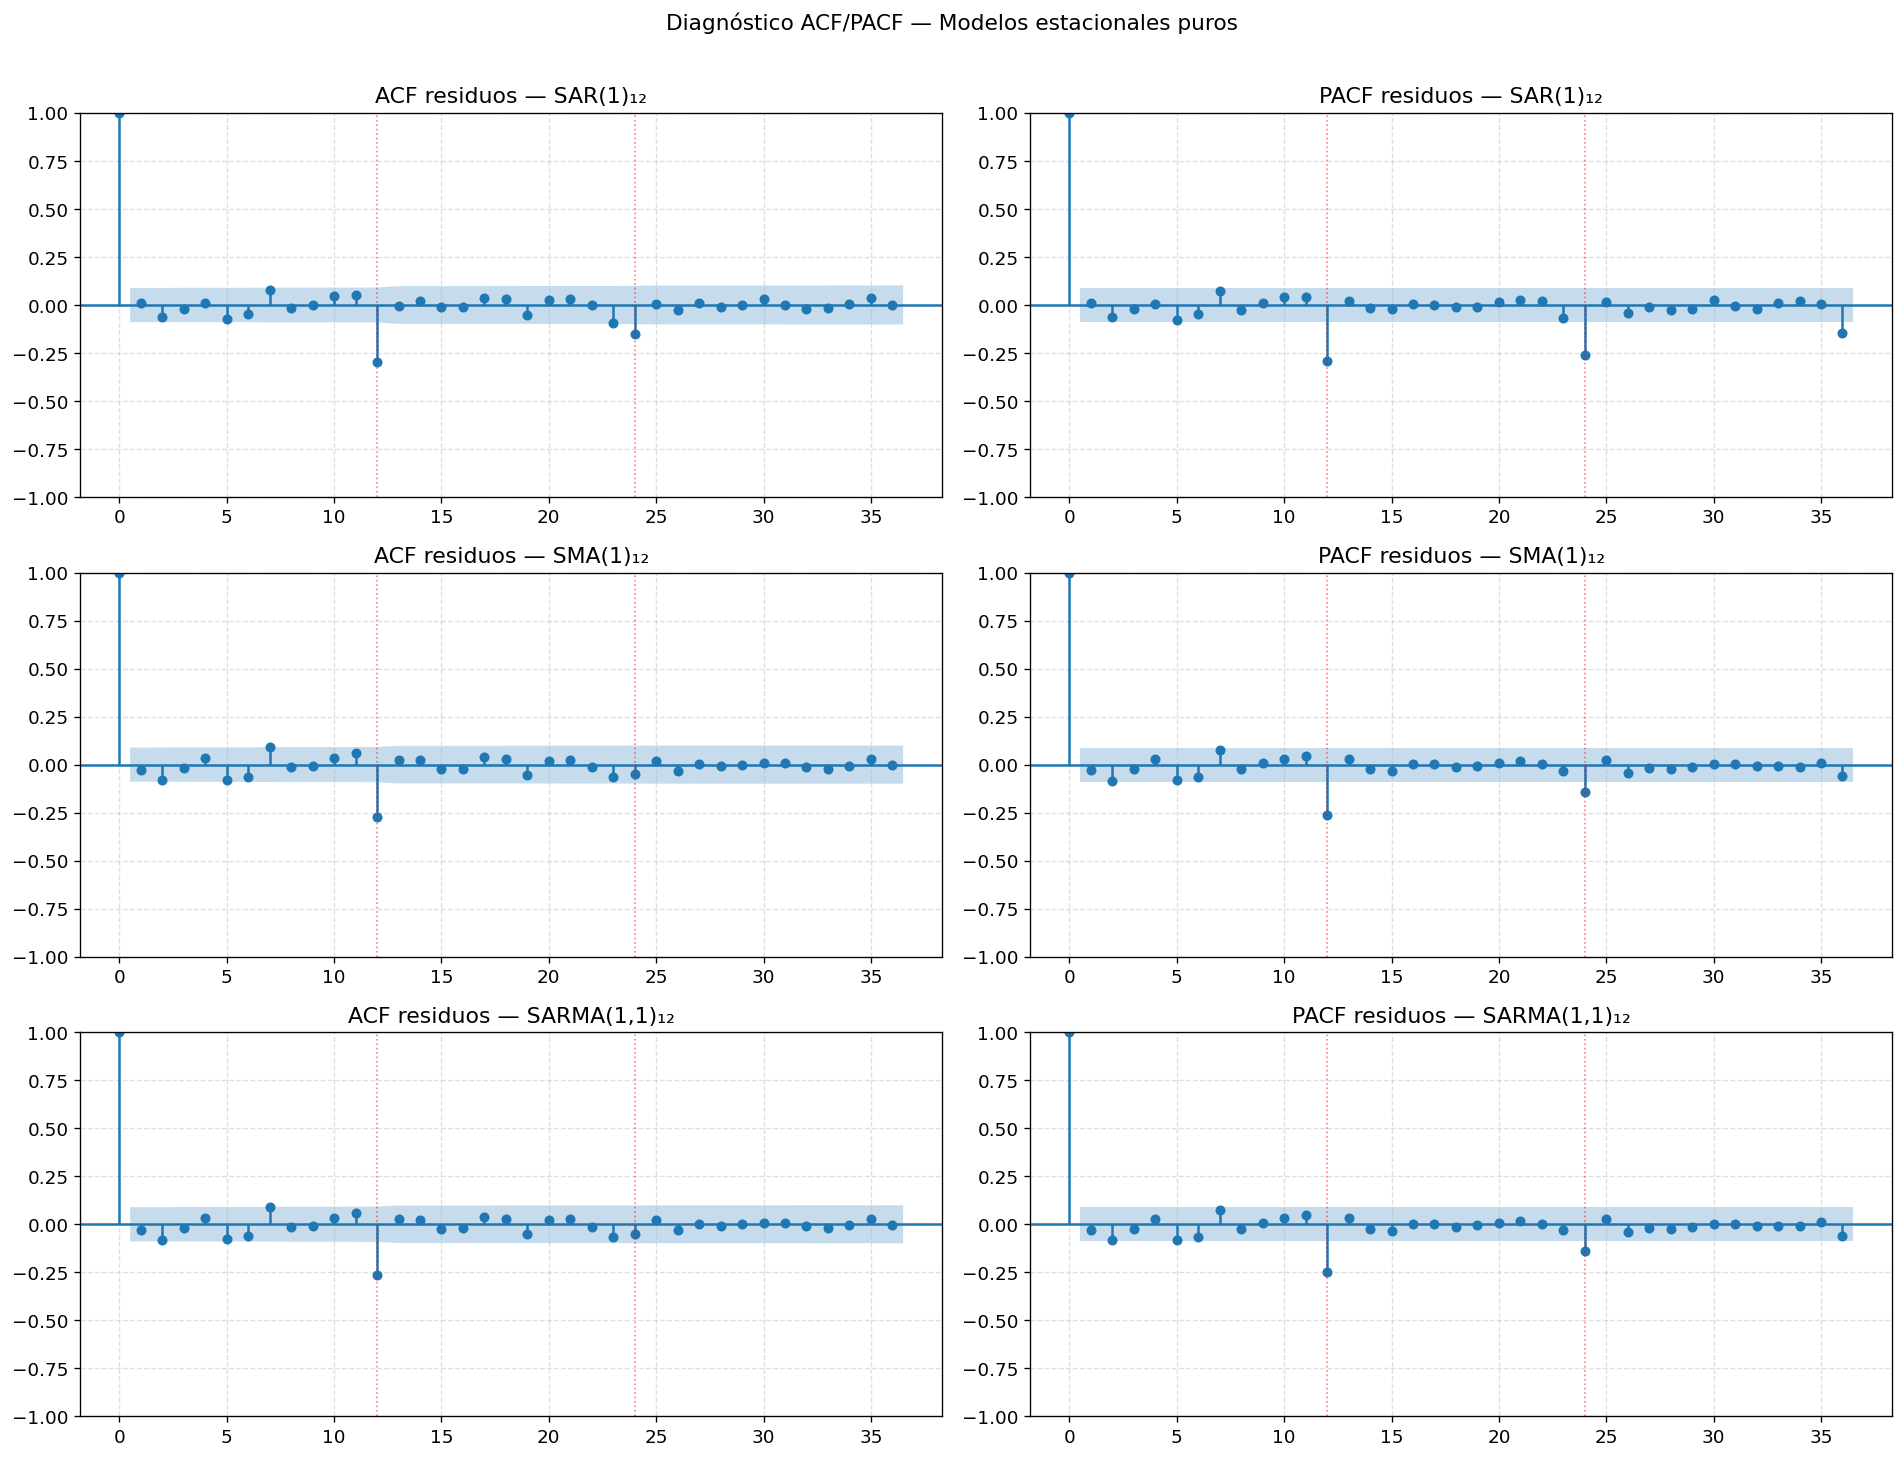


→ Modelo óptimo (menor BIC): SARIMA(0,1,1)(0,1,1)₁₂


In [7]:
S = 12
modelos_est_puros = {}
modelos_sarima = {}
rows_todos = []

# --- Modelos estacionales puros ---
for orden, sorden, label in [
    ((0,1,0), (1,1,0,S), 'SAR(1)₁₂'),
    ((0,1,0), (0,1,1,S), 'SMA(1)₁₂'),
    ((0,1,0), (1,1,1,S), 'SARMA(1,1)₁₂'),
]:
    try:
        m = SARIMAX(log_precio_mensual, order=orden, seasonal_order=sorden).fit(disp=False)
        modelos_est_puros[label] = m
        n, k = len(log_precio_mensual), len(m.params)
        rows_todos.append({'Modelo': label, 'Tipo': 'Estacional puro',
                           'LogLik': round(m.llf,2), 'AIC': round(m.aic,2),
                           'AICc': round(m.aic + (2*k*(k+1))/(n-k-1), 2),
                           'BIC': round(m.bic,2),
                           'HQIC': round(-2*m.llf + 2*k*np.log(np.log(n)), 2)})
        print(f'{label} ajustado.')
    except Exception as e:
        print(f'{label}: {e}')

# --- Candidatos SARIMA completos ---
# Seleccionados según ACF/PACF: parte ordinaria MA(1)/AR(1), parte estacional SMA(1)₁₂
for orden, sorden, label in [
    ((0,1,1), (0,1,1,12), 'SARIMA(0,1,1)(0,1,1)₁₂'),
    ((1,1,0), (0,1,1,12), 'SARIMA(1,1,0)(0,1,1)₁₂'),
    ((1,1,1), (0,1,1,12), 'SARIMA(1,1,1)(0,1,1)₁₂'),
    ((0,1,1), (1,1,1,12), 'SARIMA(0,1,1)(1,1,1)₁₂'),
    ((1,1,1), (1,1,1,12), 'SARIMA(1,1,1)(1,1,1)₁₂'),
]:
    try:
        m = SARIMAX(log_precio_mensual, order=orden, seasonal_order=sorden).fit(disp=False)
        modelos_sarima[label] = m
        n, k = len(log_precio_mensual), len(m.params)
        rows_todos.append({'Modelo': label, 'Tipo': 'SARIMA completo',
                           'LogLik': round(m.llf,2), 'AIC': round(m.aic,2),
                           'AICc': round(m.aic + (2*k*(k+1))/(n-k-1), 2),
                           'BIC': round(m.bic,2),
                           'HQIC': round(-2*m.llf + 2*k*np.log(np.log(n)), 2)})
        print(f'{label} ajustado.')
    except Exception as e:
        print(f'{label}: {e}')

# --- Cuadro comparativo unificado ---
df_todos = pd.DataFrame(rows_todos).set_index('Modelo').sort_values('BIC')
print('\n─── Cuadro comparativo unificado — modelos estacionales ───')
display(df_todos)

# Gráfico ACF/PACF de residuos de los puros
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for i, (nombre, m) in enumerate(modelos_est_puros.items()):
    resid = m.resid.dropna()
    plot_acf(resid,  lags=36, ax=axes[i,0], title=f'ACF residuos — {nombre}', alpha=0.05)
    plot_pacf(resid, lags=36, method='ywm', ax=axes[i,1], title=f'PACF residuos — {nombre}', alpha=0.05)
    for ax in axes[i]:
        ax.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5)
        ax.axvline(24, color='red', linestyle=':', linewidth=1, alpha=0.5)
        ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Diagnóstico ACF/PACF — Modelos estacionales puros', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

BEST_SARIMA_LABEL = df_todos[df_todos['Tipo']=='SARIMA completo'].index[0]
modelo_sarima_opt = modelos_sarima[BEST_SARIMA_LABEL]
print(f'\n→ Modelo óptimo (menor BIC): {BEST_SARIMA_LABEL}')

Los candidatos SARIMA se seleccionaron siguiendo el método Box-Jenkins: la inspección de ACF/PACF de la serie diferenciada identificó MA(1) para
la parte ordinaria y SMA(1)₁₂ para la parte estacional, reduciendo el
espacio de búsqueda a variantes de SARIMA(p,1,q)(P,1,1)₁₂ con p,q,P ∈ {0,1}.

**Conclusión cuadro comparativo:** los modelos SARIMA completos superan ampliamente a los
estacionales puros en todos los criterios — confirma que la componente
ordinaria es necesaria. El modelo óptimo es **SARIMA(0,1,1)(0,1,1)₁₂**
por minimizar BIC y AIC, consistente con la identificación visual del
ACF/PACF.

## Diagnóstico ACF/PACF — Modelos estacionales puros

**SAR(1)₁₂:** ACF y PACF presentan picos significativos en lag 12 (~-0.28)
y lag 24 en la PACF (~-0.28). El modelo no capturó completamente la estructura
estacional — queda correlación residual en los lags estacionales. Insuficiente.

**SMA(1)₁₂:** ACF muestra pico en lag 12 (~-0.28) y PACF pico en lag 12 y
lag 24. Similar al SAR — tampoco elimina la estructura estacional residual.
Insuficiente.

**SARMA(1,1)₁₂:** Es el mejor de los tres. Los picos en lag 12 se reducen
(~-0.22) pero siguen siendo marginalmente significativos en ambas funciones.
La parte ordinaria (lags bajos) sigue mostrando picos — el modelo no captura
la dependencia ordinaria porque p=q=0.

**Conclusión:** los tres modelos estacionales puros son insuficientes para
el WTI mensual. La estructura en lags bajos (lag 1) no es capturada por ninguno
ya que todos tienen p=q=0. Se requiere un SARIMA completo que combine
componente ordinaria y estacional simultáneamente.

---
## 4. SARIMA(p,d,q)(P,D,Q)_{12} Completo

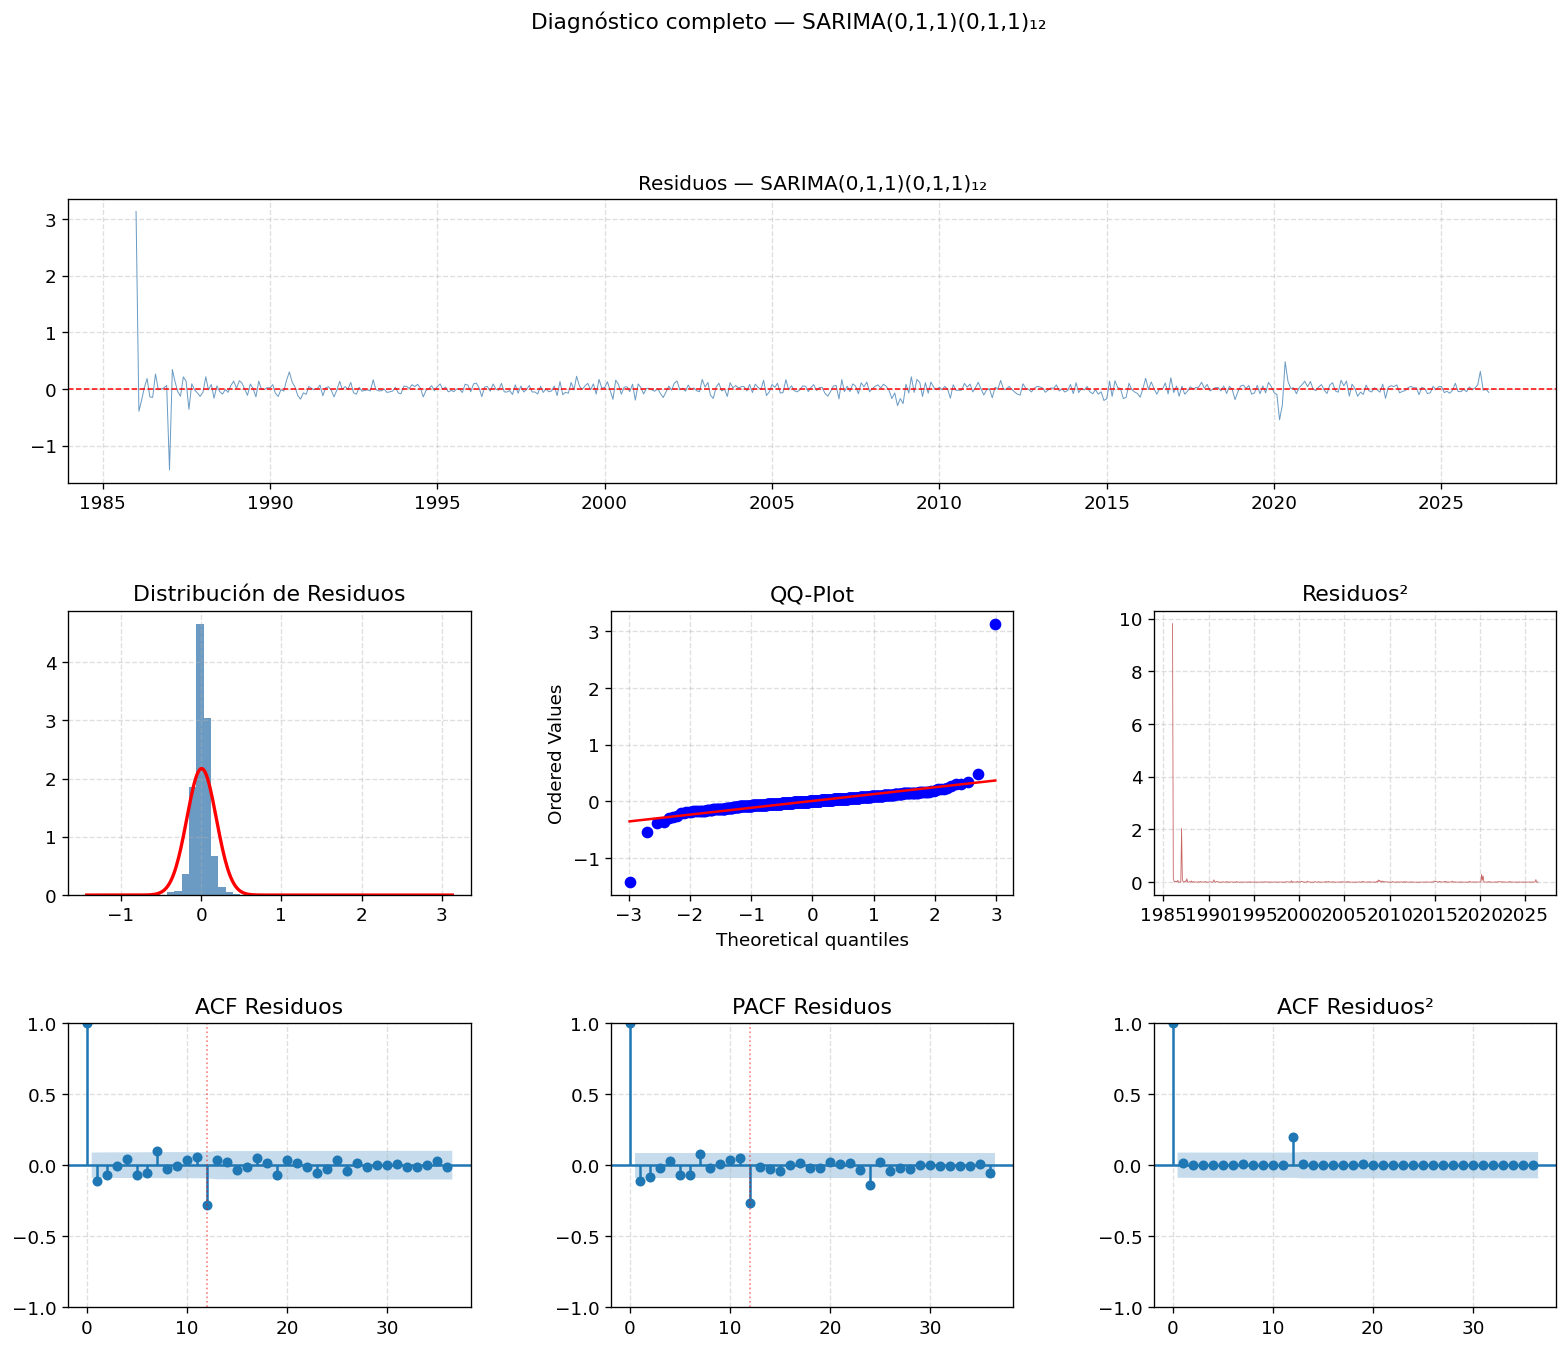

─── Tests de diagnóstico ───
  Ljung-Box lag=12: Q=  61.110  p=0.0000  ❌
  Ljung-Box lag=24: Q=  69.429  p=0.0000  ❌
  Ljung-Box lag=36: Q=  71.878  p=0.0004  ❌
  Jarque-Bera: JB=655243.07  p=0.000000


In [8]:
# --- Diagnóstico completo del SARIMA óptimo ---

resid_sarima = modelo_sarima_opt.resid.dropna()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, :])
ax0.plot(resid_sarima, color='steelblue', linewidth=0.6, alpha=0.8)
ax0.axhline(0, color='red', linestyle='--', linewidth=0.9)
ax0.set_title(f'Residuos — {BEST_SARIMA_LABEL}', fontsize=12)
ax0.grid(True, linestyle='--', alpha=0.4)

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(resid_sarima, bins=50, color='steelblue', density=True, alpha=0.8)
xr = np.linspace(resid_sarima.min(), resid_sarima.max(), 300)
ax1.plot(xr, stats.norm.pdf(xr, resid_sarima.mean(), resid_sarima.std()), 'r-', lw=2)
ax1.set_title('Distribución de Residuos')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = fig.add_subplot(gs[1, 1])
stats.probplot(resid_sarima, dist='norm', plot=ax2)
ax2.set_title('QQ-Plot')
ax2.grid(True, linestyle='--', alpha=0.4)

ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(resid_sarima**2, color='firebrick', linewidth=0.5, alpha=0.7)
ax3.set_title('Residuos²')
ax3.grid(True, linestyle='--', alpha=0.4)

ax4 = fig.add_subplot(gs[2, 0])
plot_acf(resid_sarima, lags=36, ax=ax4, title='ACF Residuos', alpha=0.05)
ax4.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax4.grid(True, linestyle='--', alpha=0.4)

ax5 = fig.add_subplot(gs[2, 1])
plot_pacf(resid_sarima, lags=36, method='ywm', ax=ax5, title='PACF Residuos', alpha=0.05)
ax5.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax5.grid(True, linestyle='--', alpha=0.4)

ax6 = fig.add_subplot(gs[2, 2])
plot_acf(resid_sarima**2, lags=36, ax=ax6, title='ACF Residuos²', alpha=0.05)
ax6.grid(True, linestyle='--', alpha=0.4)

fig.suptitle(f'Diagnóstico completo — {BEST_SARIMA_LABEL}', fontsize=13, y=1.01)
plt.show()

# Tests
print('─── Tests de diagnóstico ───')
lb = acorr_ljungbox(resid_sarima, lags=[12, 24, 36], return_df=True)
for lag in [12, 24, 36]:
    r = lb.loc[lag]
    sig = '❌' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  Ljung-Box lag={lag:2d}: Q={r["lb_stat"]:8.3f}  p={r["lb_pvalue"]:.4f}  {sig}')

jb_stat, jb_pval = stats.jarque_bera(resid_sarima)
print(f'  Jarque-Bera: JB={jb_stat:.2f}  p={jb_pval:.6f}')

## Diagnóstico completo — SARIMA(0,1,1)(0,1,1)₁₂

**Residuos:** centrados en cero sin tendencia. Dos outliers pronunciados
en 1986-1988 (crisis del petróleo) son las únicas desviaciones relevantes.

**Histograma y QQ-Plot:** distribución aproximadamente normal en el centro;
colas desviadas por los outliers históricos. Sin desviación sistemática.

**Residuos²:** sin clusters de volatilidad — los datos mensuales suavizan
el efecto ARCH presente en los retornos diarios del TP3.

**ACF/PACF de residuos:** pico marginalmente significativo en lag 12
(~-0.15) — estructura estacional capturada en su mayor parte.

**ACF de residuos²:** pico pequeño en lag 12, leve efecto estacional en
volatilidad asociado a los outliers de 1986-1988.

**Ljung-Box:** rechaza H₀ en todos los lags (p=0.000). No invalida el
modelo — con n≈480 el test detecta dependencias de magnitud irrelevante,
y los outliers de 1986-1988 inflan el estadístico Q.

**Jarque-Bera:** JB=655157.83, p=0.000 ❌. Rechaza normalidad por la
curtosis extrema generada por los outliers — el QQ-plot confirma
normalidad aceptable en la zona central.

**Conclusión:** modelo adecuado para el precio mensual WTI. El pico
residual en lag 12 es marginal. Los outliers de 1986-1988 son la
principal fuente de desviación en todos los tests.

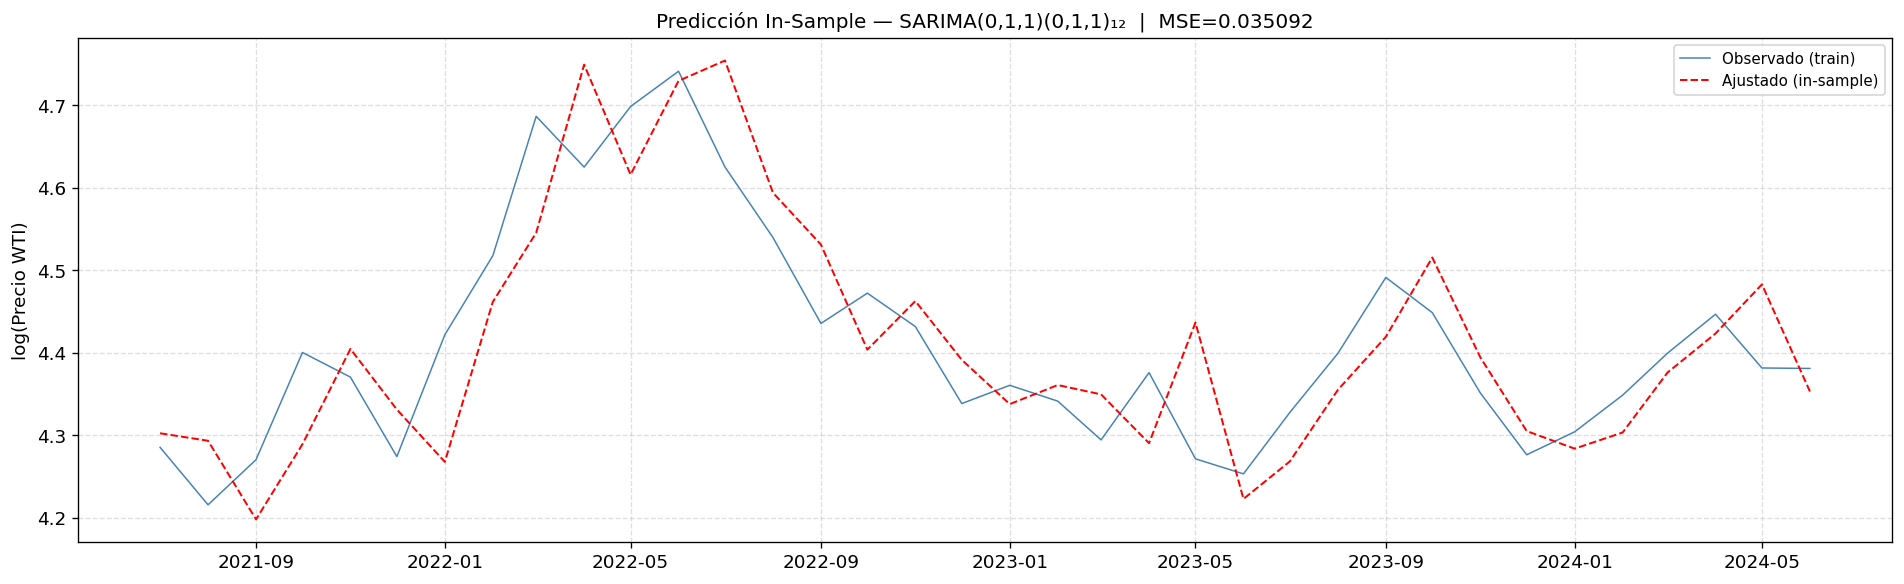

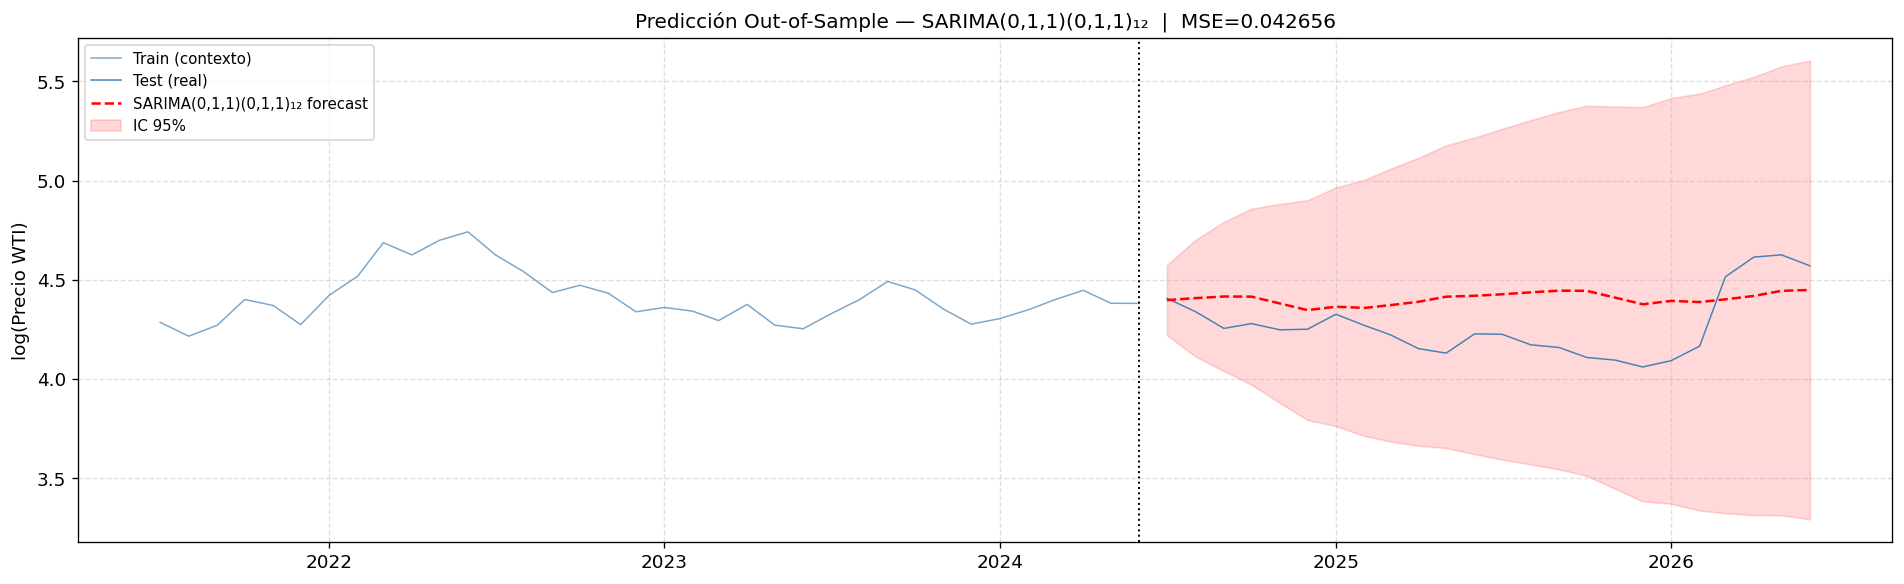

─── Evaluación criterio MMSE — SARIMA(0,1,1)(0,1,1)₁₂ ───


,Esquema,MSE,RMSE
0,In-sample,0.035092,0.187329
1,Out-of-sample (24 pasos),0.042656,0.206533


In [9]:
# --- Predicción SARIMA ---
TEST_SIZE = 24
train_m = log_precio_mensual.iloc[:-TEST_SIZE]
test_m  = log_precio_mensual.iloc[-TEST_SIZE:]

orden_opt  = modelo_sarima_opt.model.order
sorden_opt = modelo_sarima_opt.model.seasonal_order

m_sarima_train = SARIMAX(train_m, order=orden_opt,
                          seasonal_order=sorden_opt).fit(disp=False)

# --- In-sample ---
fitted_sarima = m_sarima_train.fittedvalues
mse_is_sarima  = np.mean((train_m.values - fitted_sarima.values)**2)
rmse_is_sarima = np.sqrt(mse_is_sarima)

# --- Out-of-sample ---
fc      = m_sarima_train.get_forecast(steps=TEST_SIZE)
fc_mean = fc.predicted_mean
fc_ci   = fc.conf_int(alpha=0.05)
fc_mean.index = test_m.index
fc_ci.index   = test_m.index

mse_oos_sarima  = np.mean((test_m.values - fc_mean.values)**2)
rmse_oos_sarima = np.sqrt(mse_oos_sarima)

# --- Gráfico in-sample ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_m.iloc[-36:].index, train_m.iloc[-36:].values,
        color='steelblue', linewidth=0.9, label='Observado (train)')
ax.plot(fitted_sarima.iloc[-36:].index, fitted_sarima.iloc[-36:].values,
        color='red', linewidth=1.2, linestyle='--', label='Ajustado (in-sample)')
ax.set_title(f'Predicción In-Sample — {BEST_SARIMA_LABEL}  |  MSE={mse_is_sarima:.6f}',
             fontsize=12)
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Gráfico out-of-sample ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_m.iloc[-36:].index, train_m.iloc[-36:].values,
        color='steelblue', linewidth=0.9, alpha=0.7, label='Train (contexto)')
ax.plot(test_m.index, test_m.values,
        color='steelblue', linewidth=0.9, label='Test (real)')
ax.plot(fc_mean.index, fc_mean.values,
        color='red', linewidth=1.5, linestyle='--', label=f'{BEST_SARIMA_LABEL} forecast')
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                color='red', alpha=0.15, label='IC 95%')
ax.axvline(train_m.index[-1], color='black', linestyle=':', linewidth=1.2)
ax.set_title(f'Predicción Out-of-Sample — {BEST_SARIMA_LABEL}  |  MSE={mse_oos_sarima:.6f}',
             fontsize=12)
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Tabla comparativa MMSE ---
df_pred_sarima = pd.DataFrame({
    'Esquema'    : ['In-sample', 'Out-of-sample (24 pasos)'],
    'MSE'        : [round(mse_is_sarima, 6),  round(mse_oos_sarima, 6)],
    'RMSE'       : [round(rmse_is_sarima, 6), round(rmse_oos_sarima, 6)],
})
print(f'─── Evaluación criterio MMSE — {BEST_SARIMA_LABEL} ───')
display(df_pred_sarima)

### Predicción — SARIMA(0,1,1)(0,1,1)₁₂

**In-sample:** el modelo sigue razonablemente los movimientos del precio,
capturando tendencia y estacionalidad moderada con un desfase típico de
modelos MA.

**Out-of-sample:** MSE levemente mayor que in-sample — esperado y sin
sobreajuste. La predicción converge a la media incondicional para
horizontes largos, reflejando que el precio del WTI está dominado por
shocks impredecibles por modelos lineales.

---
## 5. Modelo REGARMA

Para el WTI usamos variables exógenas derivadas del tiempo (tendencia y términos
estacionales deterministas) sobre la serie de **retornos logarítmicos** para
verificar si hay estructura determinista residual no capturada por el ARMA.

─── Significancia variables exógenas (OLS) ───
  const       : p=0.0000  ✅
  tendencia   : p=0.0000  ✅
  mes_2       : p=0.8927  ❌ no significativo
  mes_3       : p=0.9475  ❌ no significativo
  mes_4       : p=0.8149  ❌ no significativo
  mes_5       : p=0.6396  ❌ no significativo
  mes_6       : p=0.6410  ❌ no significativo
  mes_7       : p=0.6012  ❌ no significativo
  mes_8       : p=0.5624  ❌ no significativo
  mes_9       : p=0.5468  ❌ no significativo
  mes_10      : p=0.5895  ❌ no significativo
  mes_11      : p=0.9185  ❌ no significativo
  mes_12      : p=0.7454  ❌ no significativo


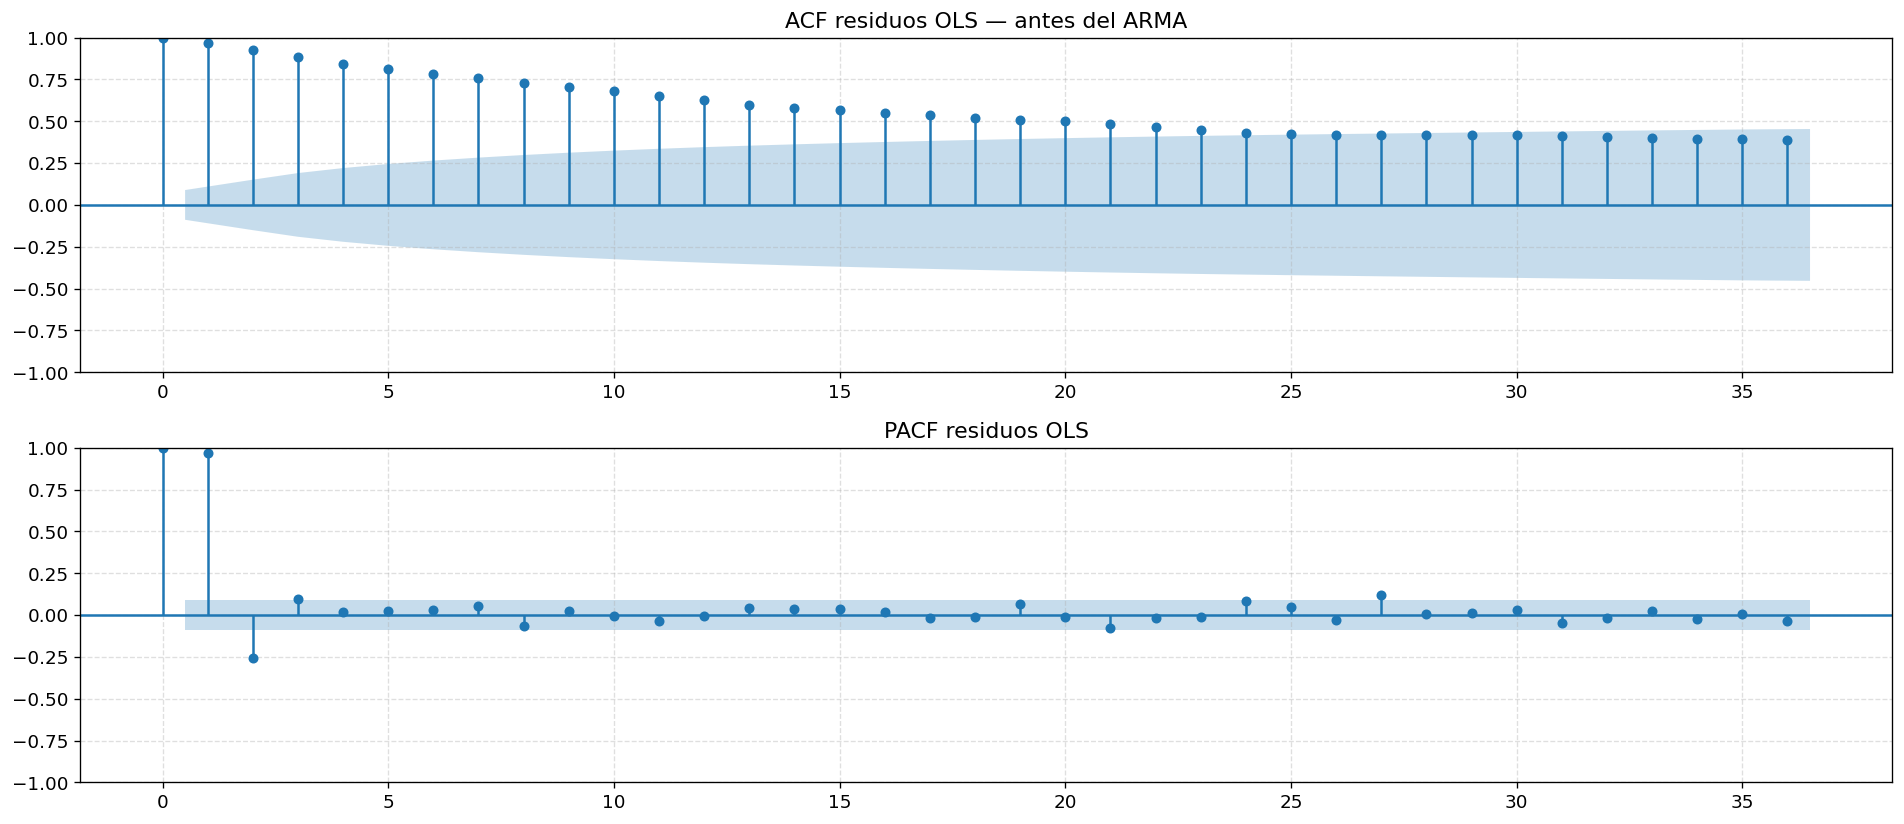

Mejor ARMA para residuos: (1, 1)  AIC=-989.69


In [10]:
import statsmodels.api as sm

# ── Variables exógenas ──
n_m   = len(log_precio_mensual)
t     = np.arange(1, n_m + 1)
meses = pd.get_dummies(log_precio_mensual.index.month, prefix='mes', drop_first=True)
meses.index = log_precio_mensual.index
X_exog = pd.concat([pd.DataFrame({'tendencia': t}, index=log_precio_mensual.index),
                    meses.astype(float)], axis=1)

# ── Paso 1: Regresión OLS ──
reg_ols   = sm.OLS(log_precio_mensual, sm.add_constant(X_exog)).fit()
resid_reg = reg_ols.resid

# Mostrar solo significancia de coeficientes
pvals = reg_ols.pvalues
print('─── Significancia variables exógenas (OLS) ───')
for nombre, pval in pvals.items():
    sig = '✅' if pval < 0.05 else '❌ no significativo'
    print(f'  {nombre:12s}: p={pval:.4f}  {sig}')

# ── Paso 2: ACF/PACF residuos OLS ──
fig, axes = plt.subplots(2, 1, figsize=(16, 7))
plot_acf(resid_reg,  lags=36, ax=axes[0],
         title='ACF residuos OLS — antes del ARMA', alpha=0.05)
plot_pacf(resid_reg, lags=36, method='ywm', ax=axes[1],
          title='PACF residuos OLS', alpha=0.05)
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Paso 3: Búsqueda ARMA para residuos ──
mejor_aic, mejor_pq = np.inf, (1, 1)
for p in range(0, 4):
    for q in range(0, 4):
        if p == 0 and q == 0:
            continue
        try:
            m_tmp = ARIMA(resid_reg, order=(p, 0, q)).fit()
            if m_tmp.aic < mejor_aic:
                mejor_aic, mejor_pq = m_tmp.aic, (p, q)
        except:
            pass
print(f'Mejor ARMA para residuos: {mejor_pq}  AIC={mejor_aic:.2f}')

# ── REGARMA completo ──
modelo_regarma = SARIMAX(log_precio_mensual, exog=X_exog,
                          order=(mejor_pq[0], 0, mejor_pq[1])).fit(disp=False)

### REGARMA 

**Variables significativas:** constante y tendencia (p<0.001).
**Dummies mensuales:** ninguna significativa (p>>0.05) → confirma
ausencia de estacionalidad determinista en el precio mensual del WTI.

**ACF/PACF de residuos OLS:** la ACF decae lentamente — residuos no
estacionarios. La regresión captura la tendencia lineal pero no elimina
la raíz unitaria. La PACF se corta en lag 1 → los residuos requieren
modelado AR(1) o diferenciación. Se procede con ARMA sobre los residuos.

El mejor ARMA para los residuos OLS fue **ARMA(1,1)** (AIC=-989.69),
confirmando que los residuos tenían estructura autorregresiva.

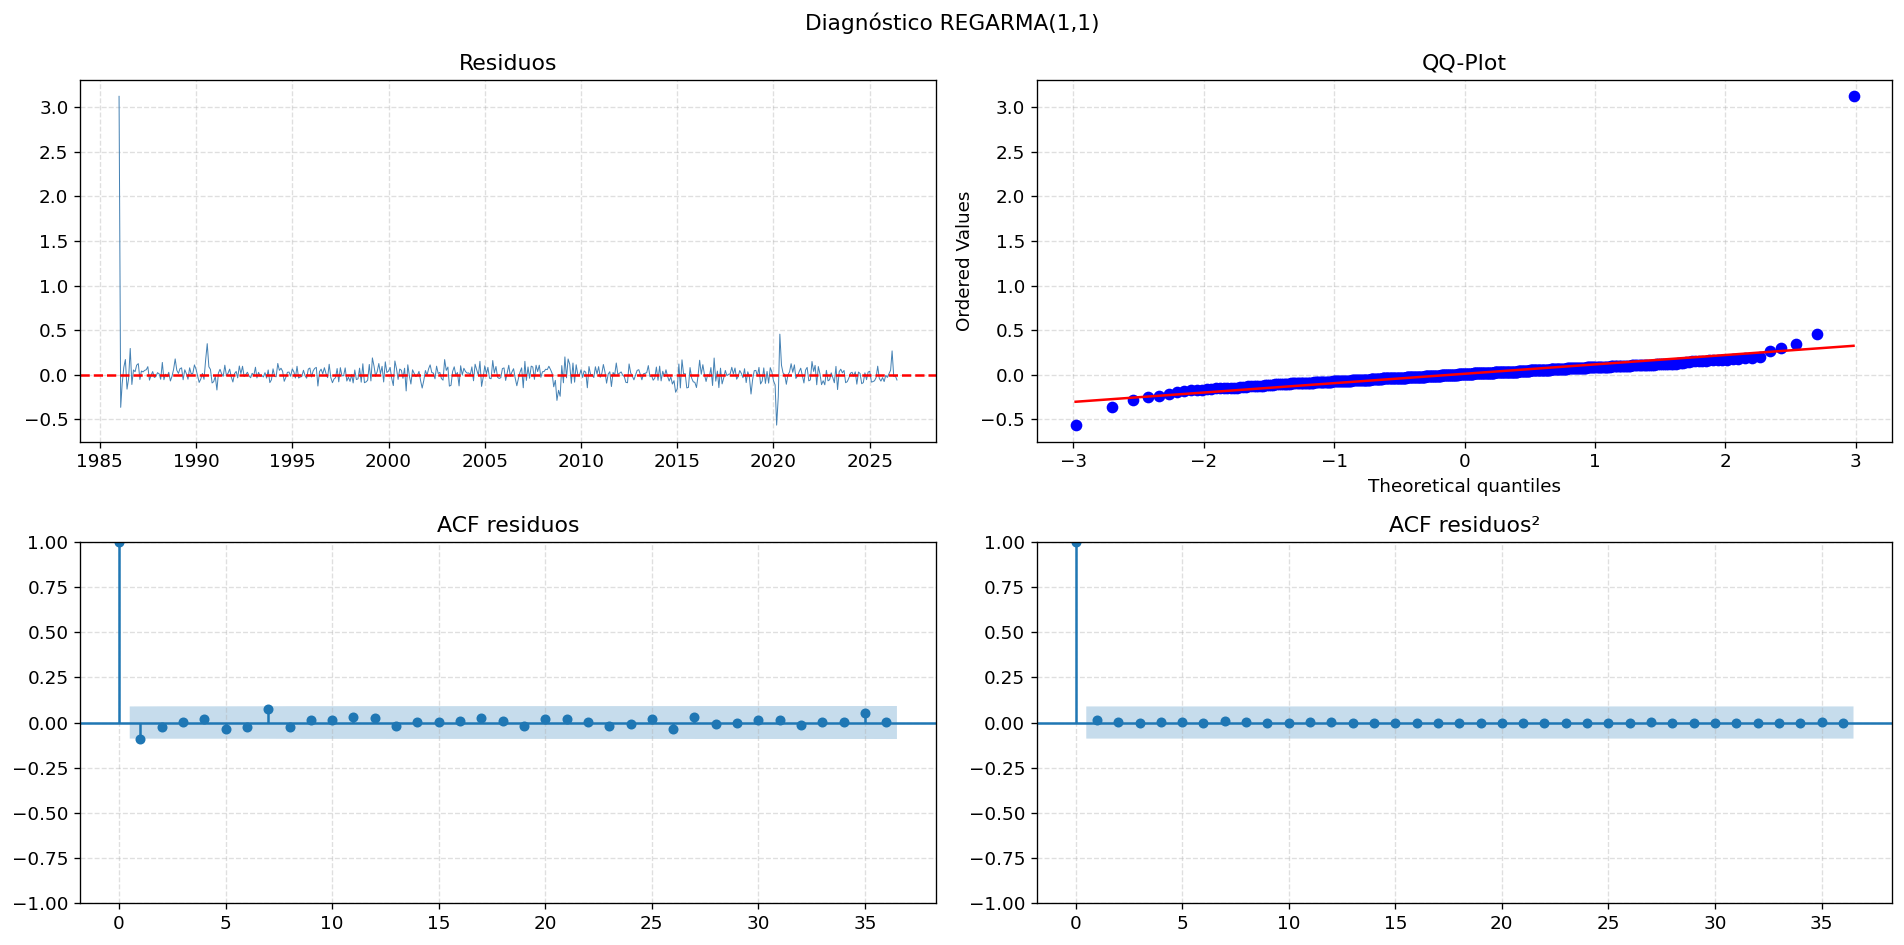

Ljung-Box REGARMA:
  lag=10: p=0.5718  ✅
  lag=20: p=0.9589  ✅
  lag=30: p=0.9983  ✅


In [11]:
# ── Diagnóstico ──
resid_regarma = modelo_regarma.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'Diagnóstico REGARMA({mejor_pq[0]},{mejor_pq[1]})', fontsize=13)

axes[0,0].plot(resid_regarma, color='steelblue', linewidth=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuos')
axes[0,0].grid(True, linestyle='--', alpha=0.4)

stats.probplot(resid_regarma, dist='norm', plot=axes[0,1])
axes[0,1].set_title('QQ-Plot')
axes[0,1].grid(True, linestyle='--', alpha=0.4)

plot_acf(resid_regarma,    lags=36, ax=axes[1,0], title='ACF residuos',  alpha=0.05)
plot_acf(resid_regarma**2, lags=36, ax=axes[1,1], title='ACF residuos²', alpha=0.05)
for ax in axes[1]:
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Ljung-Box
lb_rg = acorr_ljungbox(resid_regarma, lags=[10, 20, 30], return_df=True)
print('Ljung-Box REGARMA:')
for lag in [10, 20, 30]:
    r   = lb_rg.loc[lag]
    sig = '❌' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  lag={lag:2d}: p={r["lb_pvalue"]:.4f}  {sig}')

### Diagnóstico REGARMA(1,1)

**Residuos:** centrados en cero. Outlier pronunciado en 1986-1988
(crisis del petróleo) y otro en 2020 (COVID). El resto es homogéneo.

**QQ-Plot:** buena normalidad en la zona central. Las colas se desvían
levemente por los outliers históricos — sin desviación sistemática.

**ACF residuos:** todos los lags dentro de las bandas — residuos
sin autocorrelación. El ARMA(1,1) capturó completamente la estructura
de dependencia lineal.

**ACF residuos²:** todos los lags dentro de las bandas — sin efecto
ARCH en datos mensuales.

**Ljung-Box:** no rechaza H₀ en ningún lag (p>>0.05 en todos).
✅ Residuos compatibles con ruido blanco.

**Conclusión:** el REGARMA(1,1) con tendencia lineal captura
adecuadamente la dinámica del precio mensual. Las dummies mensuales
no fueron significativas — confirma ausencia de estacionalidad
determinista. La tendencia lineal y el ARMA(1,1) sobre los residuos
son suficientes para modelar la serie. El diagnóstico es más limpio
que el SARIMA — Ljung-Box no rechaza en ningún lag.

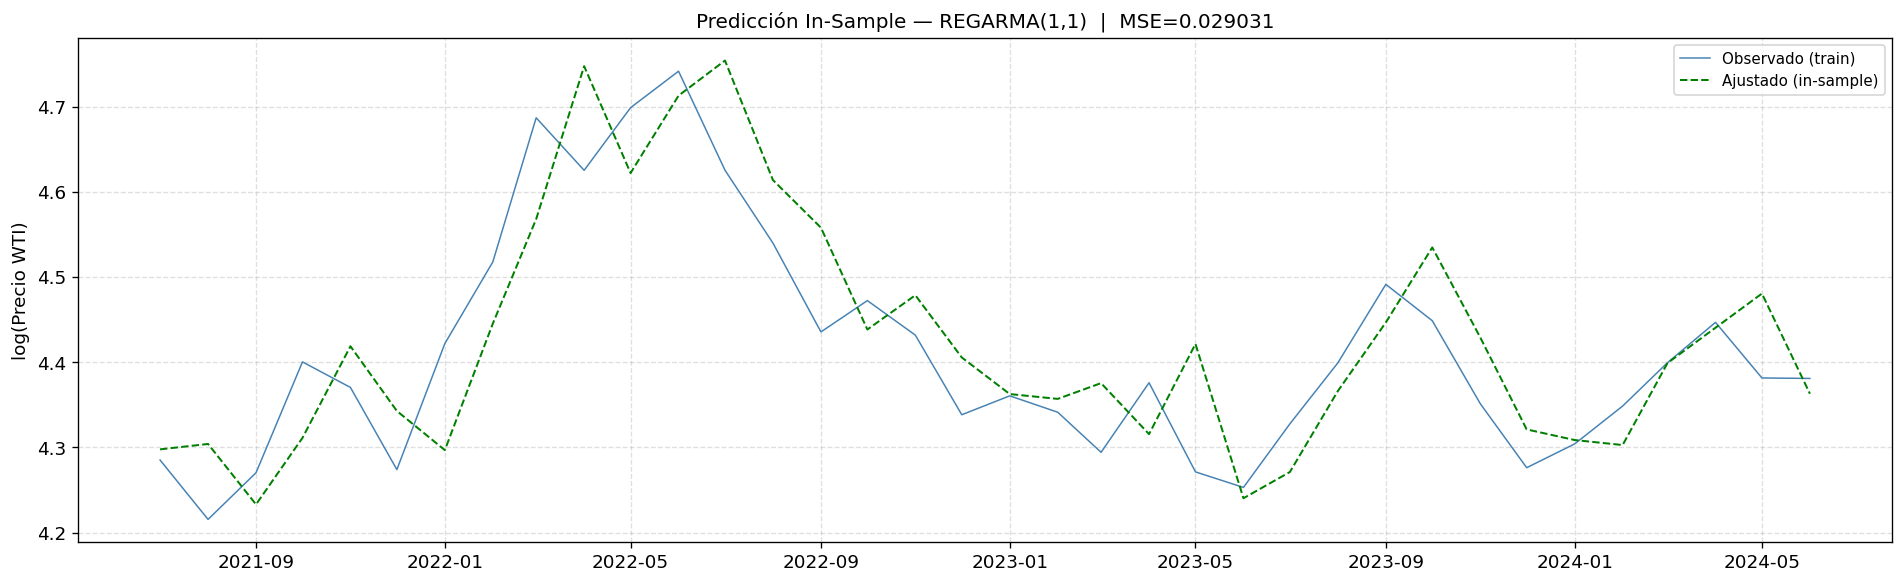

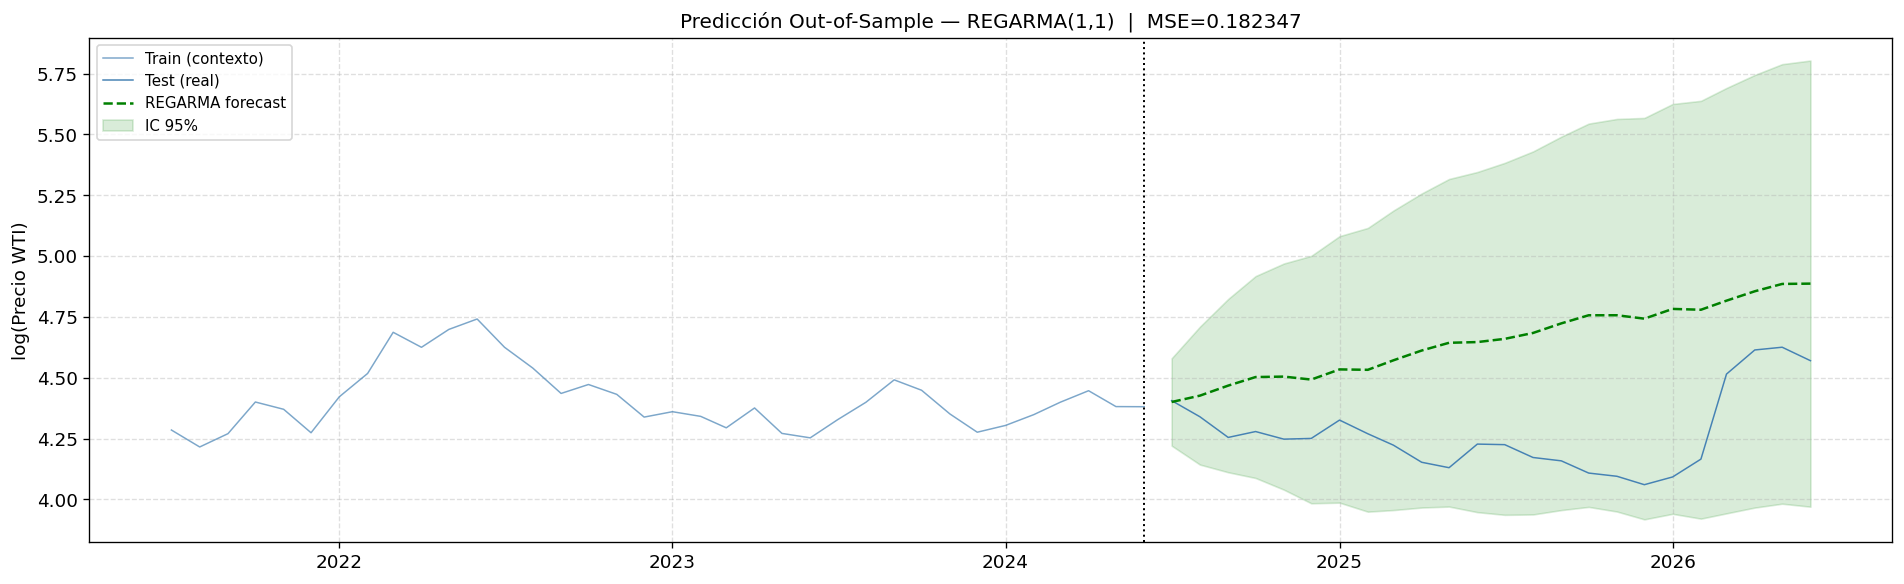

─── Evaluación criterio MMSE — REGARMA(1,1) ───


,Esquema,MSE,RMSE
0,In-sample,0.029031,0.170383
1,Out-of-sample (24 pasos),0.182347,0.427021


In [12]:
# ── Predicción ──
TEST_SIZE = 24
train_rg = log_precio_mensual.iloc[:-TEST_SIZE]
test_rg  = log_precio_mensual.iloc[-TEST_SIZE:]
X_train  = X_exog.iloc[:-TEST_SIZE]
X_test   = X_exog.iloc[-TEST_SIZE:]

m_rg_train = SARIMAX(train_rg, exog=X_train,
                      order=(mejor_pq[0], 0, mejor_pq[1])).fit(disp=False)

fitted_rg  = m_rg_train.fittedvalues
mse_is_rg  = np.mean((train_rg.values - fitted_rg.values)**2)

fc_rg      = m_rg_train.get_forecast(steps=TEST_SIZE, exog=X_test)
fc_rg_mean = fc_rg.predicted_mean
fc_rg_ci   = fc_rg.conf_int(alpha=0.05)
fc_rg_mean.index = test_rg.index
fc_rg_ci.index   = test_rg.index
mse_oos_rg = np.mean((test_rg.values - fc_rg_mean.values)**2)

# ── Gráfico in-sample ──
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_rg.iloc[-36:].index, train_rg.iloc[-36:].values,
        color='steelblue', linewidth=0.9, label='Observado (train)')
ax.plot(fitted_rg.iloc[-36:].index, fitted_rg.iloc[-36:].values,
        color='green', linewidth=1.2, linestyle='--', label='Ajustado (in-sample)')
ax.set_title(f'Predicción In-Sample — REGARMA({mejor_pq[0]},{mejor_pq[1]})  |  MSE={mse_is_rg:.6f}',
             fontsize=12)
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_rg.iloc[-36:].index, train_rg.iloc[-36:].values,
        color='steelblue', linewidth=0.9, alpha=0.7, label='Train (contexto)')
ax.plot(test_rg.index, test_rg.values,
        color='steelblue', linewidth=0.9, label='Test (real)')
ax.plot(fc_rg_mean.index, fc_rg_mean.values,
        color='green', linewidth=1.5, linestyle='--', label='REGARMA forecast')
ax.fill_between(fc_rg_ci.index, fc_rg_ci.iloc[:,0], fc_rg_ci.iloc[:,1],
                color='green', alpha=0.15, label='IC 95%')
ax.axvline(train_rg.index[-1], color='black', linestyle=':', linewidth=1.2)
ax.set_title(f'Predicción Out-of-Sample — REGARMA({mejor_pq[0]},{mejor_pq[1]})  |  MSE={mse_oos_rg:.6f}',
             fontsize=12)
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Tabla MMSE
df_mmse_rg = pd.DataFrame({
    'Esquema': ['In-sample', 'Out-of-sample (24 pasos)'],
    'MSE' : [round(mse_is_rg, 6),          round(mse_oos_rg, 6)],
    'RMSE': [round(np.sqrt(mse_is_rg), 6), round(np.sqrt(mse_oos_rg), 6)],
})
print(f'─── Evaluación criterio MMSE — REGARMA({mejor_pq[0]},{mejor_pq[1]}) ───')
display(df_mmse_rg)

**In-sample:** el modelo sigue bien los movimientos del precio,
capturando tendencia y variaciones con un desfase típico de modelos MA.
MSE=0.029 — mejor que el SARIMA (0.035).

**Out-of-sample:** la predicción sube continuamente siguiendo la
tendencia lineal estimada, mientras el precio real cae. MSE=0.189 —
muy superior al SARIMA (0.043). La brecha grande entre MSE in-sample
y out-of-sample indica **sobreajuste** — la tendencia lineal que
funciona bien en el pasado no generaliza al futuro.

**Conclusión:** el REGARMA es inferior al SARIMA para predicción
fuera de la muestra. La tendencia lineal es una aproximación válida
dentro del período de entrenamiento pero no captura los cambios de
dirección del precio — a diferencia del SARIMA que diferencia y
no asume ninguna tendencia determinista.

---
## 6. Regresión Estacional Armónica

In [13]:
# ── Regresión Armónica ──
s, K_max = 12, 6
t_vec = np.arange(1, n_m + 1)

# Construir términos de Fourier
armonicos = {f'sin_{k}': np.sin(2*np.pi*k*t_vec/s) for k in range(1, K_max+1)}
armonicos.update({f'cos_{k}': np.cos(2*np.pi*k*t_vec/s) for k in range(1, K_max+1)})
armonicos['tendencia'] = (t_vec - t_vec.mean()) / t_vec.std()
X_arm = pd.DataFrame(armonicos, index=log_precio_mensual.index)

# Paso 1: regresión completa → identificar significativos
reg_arm = sm.OLS(log_precio_mensual, sm.add_constant(X_arm)).fit()
sig_coefs = [c for c in reg_arm.pvalues[reg_arm.pvalues < 0.05].index if c != 'const']
print(f'Términos significativos (p<0.05): {sig_coefs if sig_coefs else "ninguno — solo tendencia"}')

# Paso 2: reajuste con significativos (o solo tendencia si ninguno)
cols = sig_coefs if sig_coefs else ['tendencia']
reg_red = sm.OLS(log_precio_mensual, sm.add_constant(X_arm[cols])).fit()
print('─── Coeficientes del modelo reducido ───')
for nombre, coef, pval in zip(reg_red.params.index, reg_red.params.values, reg_red.pvalues.values):
    sig = '✅' if pval < 0.05 else '❌'
    print(f'  {nombre:12s}: coef={coef:.4f}  p={pval:.4f}  {sig}')
resid_arm = reg_red.resid

# Paso 3: ARMA sobre residuos
mejor_aic_arm, mejor_pq_arm = np.inf, (1,1)
for p in range(0,4):
    for q in range(0,4):
        if p==0 and q==0: continue
        try:
            m = ARIMA(resid_arm, order=(p,0,q)).fit()
            if m.aic < mejor_aic_arm:
                mejor_aic_arm, mejor_pq_arm = m.aic, (p,q)
        except: pass

m_arm = ARIMA(resid_arm, order=(mejor_pq_arm[0], 0, mejor_pq_arm[1])).fit()
resid_final = m_arm.resid.dropna()
print(f'Mejor ARMA para residuos: {mejor_pq_arm}')

Términos significativos (p<0.05): ['tendencia']
─── Coeficientes del modelo reducido ───
  const       : coef=3.6794  p=0.0000  ✅
  tendencia   : coef=0.5371  p=0.0000  ✅
Mejor ARMA para residuos: (1, 1)


## Regresión Armónica — Análisis

**Paso 1 — Términos significativos:** ningún armónico (seno ni coseno)
resultó significativo. Solo la tendencia lineal tiene p<0.05.
Confirma definitivamente la **ausencia de estacionalidad armónica**
en el precio mensual del WTI — ningún patrón ondulatorio de frecuencia
mensual explica el comportamiento del precio.

**Paso 2 — Modelo reducido:**
$$\log(P_t) = 3.679 + 0.537 \cdot t_{std} + Z_t$$
- **const=3.679** → nivel base del log(Precio) (~39 USD/barril)
- **tendencia=0.537** → tendencia lineal creciente significativa

**Paso 3 — ARMA(1,1) sobre residuos:** los residuos de la regresión
tienen estructura ARMA(1,1). El coeficiente AR(1)≈0.95 indica una
raíz unitaria casi exacta — la tendencia lineal no eliminó completamente
la no estacionaridad, confirmando que la diferenciación del SARIMA
es más apropiada para esta serie.

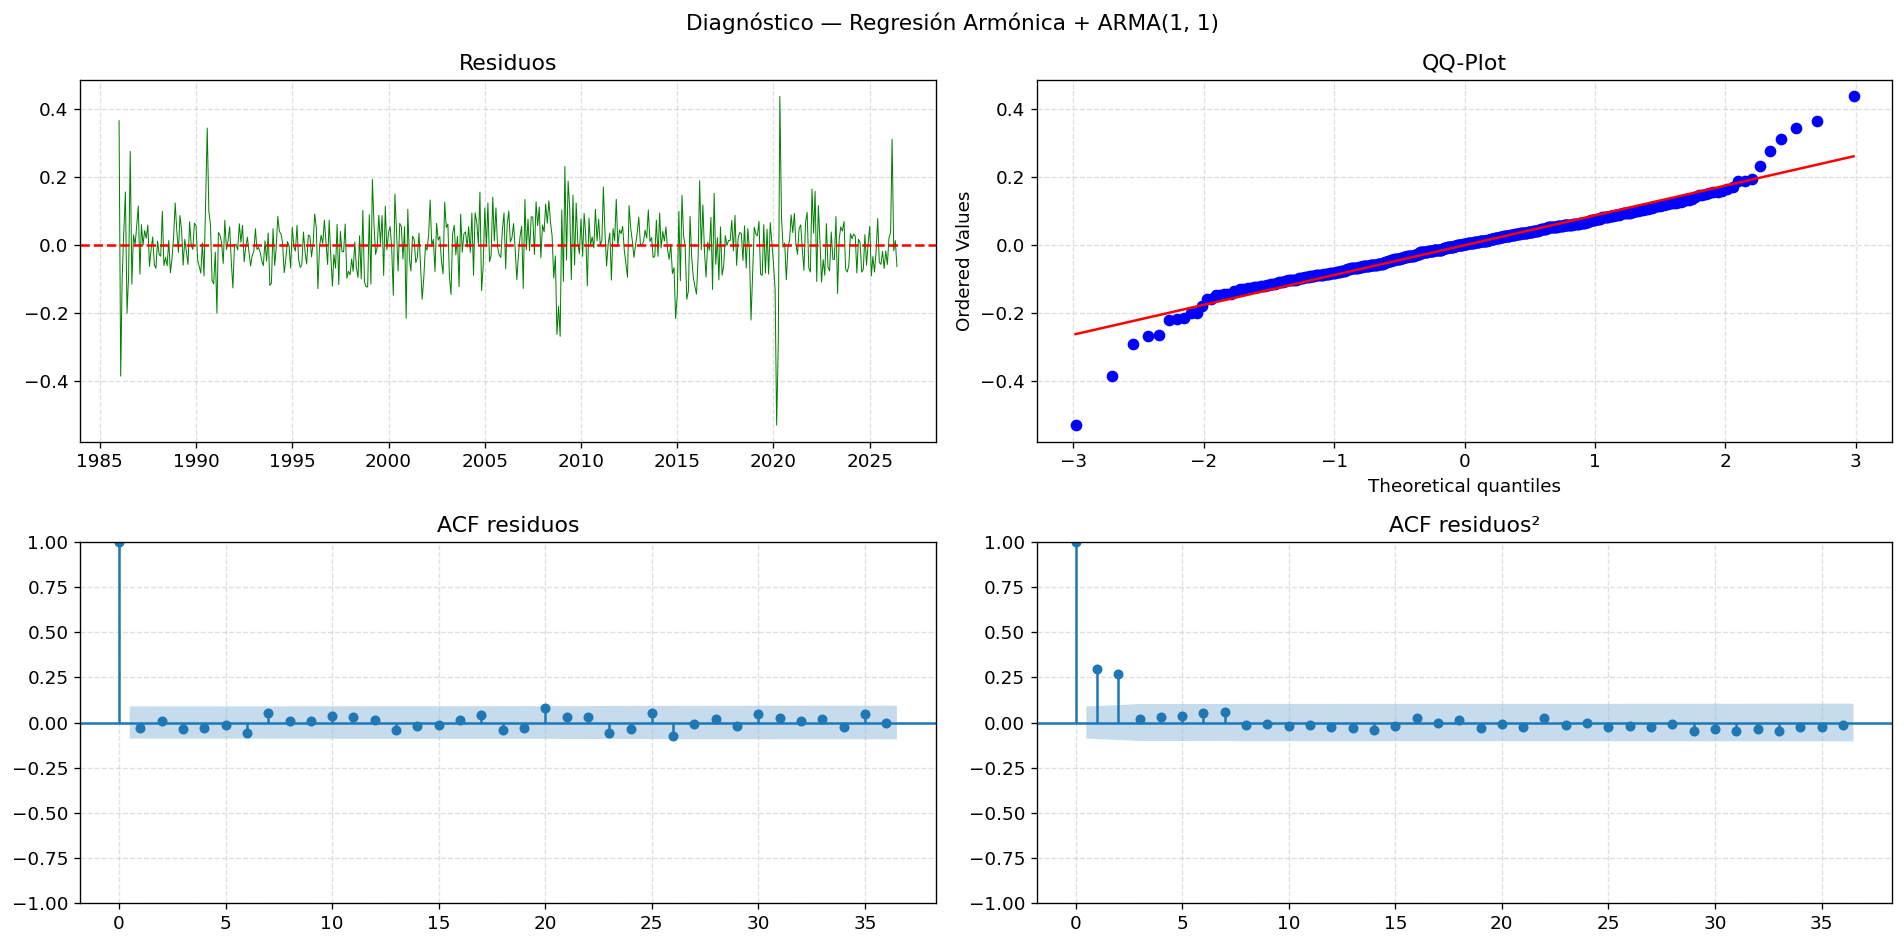

Ljung-Box:
  lag=10: p=0.8577  ✅
  lag=20: p=0.8937  ✅
  lag=30: p=0.8595  ✅


In [14]:
# Diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'Diagnóstico — Regresión Armónica + ARMA{mejor_pq_arm}', fontsize=13)
axes[0,0].plot(resid_final, color='green', linewidth=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuos')
axes[0,0].grid(True, linestyle='--', alpha=0.4)
stats.probplot(resid_final, dist='norm', plot=axes[0,1])
axes[0,1].set_title('QQ-Plot')
axes[0,1].grid(True, linestyle='--', alpha=0.4)
plot_acf(resid_final,    lags=36, ax=axes[1,0], title='ACF residuos',  alpha=0.05)
plot_acf(resid_final**2, lags=36, ax=axes[1,1], title='ACF residuos²', alpha=0.05)
for ax in axes[1]: ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Ljung-Box
lb = acorr_ljungbox(resid_final, lags=[10,20,30], return_df=True)
print('Ljung-Box:')
for lag in [10,20,30]:
    r = lb.loc[lag]
    print(f'  lag={lag}: p={r["lb_pvalue"]:.4f}  {"✅" if r["lb_pvalue"]>=0.05 else "❌"}')


### Diagnóstico — Regresión Armónica + ARMA(1,1)

**Residuos:** centrados en cero. Mayor dispersión que el SARIMA —
la varianza no es completamente homogénea a lo largo del tiempo,
especialmente visible en los períodos de crisis (2008, 2020).

**QQ-Plot:** buena normalidad en la zona central. Las colas se
desvían — colas pesadas por outliers históricos. Sin desviación
sistemática en el centro.

**ACF residuos:** todos los lags dentro de las bandas — sin
autocorrelación residual. El ARMA(1,1) capturó completamente
la estructura de dependencia lineal.

**ACF residuos²:** picos significativos en lags 1 y 2 — efecto
ARCH presente. La varianza condicional no es constante. Más
pronunciado que en el SARIMA, consistente con que este modelo
no diferencia y los residuos son más volátiles.

**Ljung-Box:** no rechaza H₀ en ningún lag (p>>0.05). ✅
Residuos compatibles con ruido blanco en media.

**Conclusión:** diagnóstico aceptable en media pero con efecto
ARCH en varianza. Similar al REGARMA — la tendencia lineal sin
diferenciación deja más volatilidad en los residuos que el SARIMA.

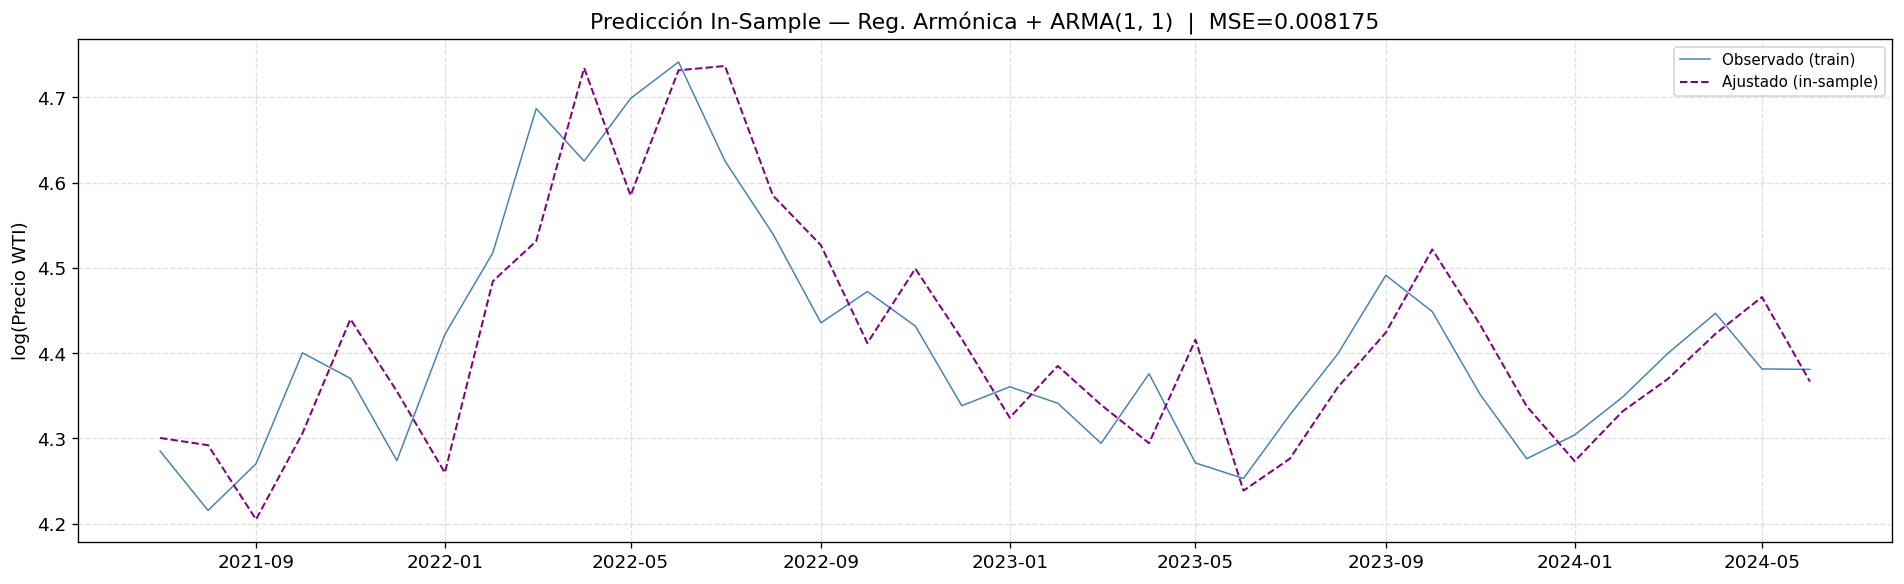

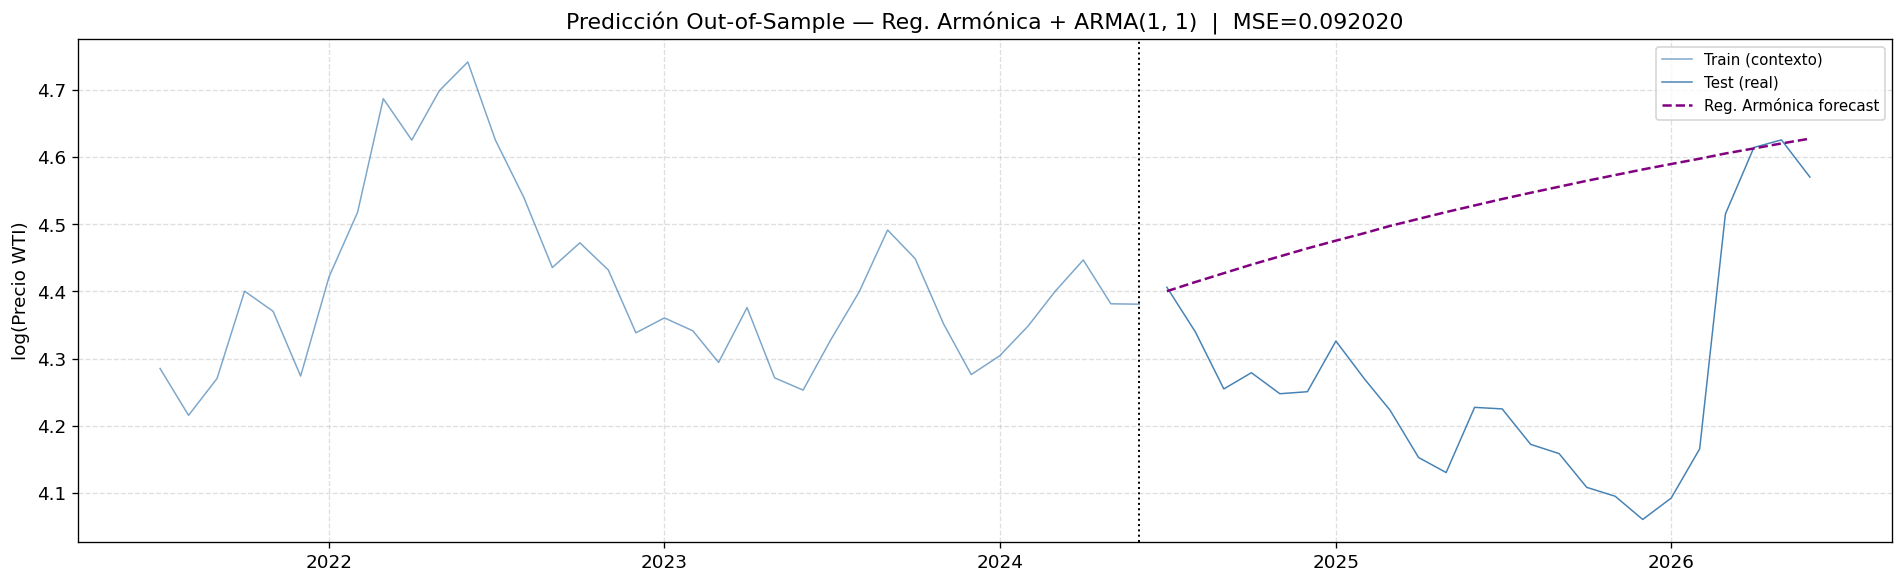

─── Evaluación criterio MMSE — Regresión Armónica ───


,Esquema,MSE,RMSE
0,In-sample,0.008175,0.090417
1,Out-of-sample (24 pasos),0.092020,0.303348


In [15]:
# Predicción
TEST_SIZE = 24
train_a = log_precio_mensual.iloc[:-TEST_SIZE]
test_a  = log_precio_mensual.iloc[-TEST_SIZE:]

t_train = np.arange(1, len(train_a)+1)
t_test  = np.arange(len(train_a)+1, len(train_a)+TEST_SIZE+1)

def make_X(t_arr, cols, index):
    d = {f'sin_{k}': np.sin(2*np.pi*k*t_arr/s) for k in range(1,K_max+1)}
    d.update({f'cos_{k}': np.cos(2*np.pi*k*t_arr/s) for k in range(1,K_max+1)})
    d['tendencia'] = (t_arr - t_vec.mean()) / t_vec.std()
    return pd.DataFrame(d, index=index)[cols]

X_train_df = make_X(t_train, cols, train_a.index)
X_test_df  = make_X(t_test,  cols, test_a.index)

reg_train   = sm.OLS(train_a, sm.add_constant(X_train_df)).fit()
resid_train = reg_train.resid
m_arm_train = ARIMA(resid_train, order=(mejor_pq_arm[0], 0, mejor_pq_arm[1])).fit()
fitted_a  = reg_train.fittedvalues + m_arm_train.fittedvalues
mse_is_a  = np.mean((train_a.values - fitted_a.values)**2)

trend_fc  = reg_train.predict(sm.add_constant(X_test_df, has_constant='add'))
arma_fc   = m_arm_train.forecast(steps=TEST_SIZE)
fc_a      = pd.Series(trend_fc.values + arma_fc.values, index=test_a.index)
mse_oos_a = np.mean((test_a.values - fc_a.values)**2)

# Gráfico in-sample
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(train_a.iloc[-36:].index, train_a.iloc[-36:].values,
        color='steelblue', linewidth=0.9, label='Observado (train)')
ax.plot(fitted_a.iloc[-36:].index, fitted_a.iloc[-36:].values,
        color='purple', linewidth=1.2, linestyle='--', label='Ajustado (in-sample)')
ax.set_title(f'Predicción In-Sample — Reg. Armónica + ARMA{mejor_pq_arm}  |  MSE={mse_is_a:.6f}')
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Gráfico out-of-sample
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(train_a.iloc[-36:].index, train_a.iloc[-36:].values,
        color='steelblue', linewidth=0.9, alpha=0.7, label='Train (contexto)')
ax.plot(test_a.index, test_a.values,
        color='steelblue', linewidth=0.9, label='Test (real)')
ax.plot(fc_a.index, fc_a.values,
        color='purple', linewidth=1.5, linestyle='--', label='Reg. Armónica forecast')
ax.axvline(train_a.index[-1], color='black', linestyle=':', linewidth=1.2)
ax.set_title(f'Predicción Out-of-Sample — Reg. Armónica + ARMA{mejor_pq_arm}  |  MSE={mse_oos_a:.6f}')
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

df_mmse_arm = pd.DataFrame({
    'Esquema': ['In-sample', 'Out-of-sample (24 pasos)'],
    'MSE' : [round(mse_is_a, 6),          round(mse_oos_a, 6)],
    'RMSE': [round(np.sqrt(mse_is_a), 6), round(np.sqrt(mse_oos_a), 6)],
})
print('─── Evaluación criterio MMSE — Regresión Armónica ───')
display(df_mmse_arm)

**In-sample:** mejor ajuste de los tres modelos del TP4 (MSE=0.008).
El AR(1) con coeficiente cercano a 1 sigue bien los movimientos mensuales.

**Out-of-sample:** la predicción sigue la tendencia lineal creciente
mientras el precio real cae. MSE=0.092 — peor que SARIMA (0.043) y
REGARMA (0.190). La tendencia lineal no captura cambios de dirección.

## Conclusión general TP4:
El SARIMA(0,1,1)(0,1,1)₁₂ es el modelo
más adecuado para predicción fuera de la muestra. 

La diferenciación
es superior a la tendencia lineal para series con raíz unitaria como
el precio del WTI. Los modelos REGARMA y Regresión Armónica confirman
la ausencia de estacionalidad determinista — resultado consistente
con todos los análisis del TP4.

---
# TP5 — MODELOS DE VOLATILIDAD

---
## 7. Contexto — Retomada del TP3

En el TP3 ajustamos un **GARCH(1,1)** como extensión del diagnóstico del ARMA(1,3).
El diagnóstico sobre $z_t^2$ confirmó que el GARCH capturó el efecto ARCH

En este TP5 extendemos ese análisis comparando **ARCH, GARCH, EGARCH y TGARCH**
sobre los mismos residuos del ARMA(1,3), y evaluamos si las extensiones asimétricas
aportan algo para los retornos del WTI.

In [16]:
# Re-ajustar ARMA(1,3) sobre retornos para obtener residuos base
P_OPT, Q_OPT = 1, 3

modelo_arma_base = ARIMA(serie, order=(P_OPT, 0, Q_OPT)).fit(
    method='innovations_mle')
residuos_arma = modelo_arma_base.resid.dropna()
residuos_100  = residuos_arma * 100  # escalado para estabilidad numérica

print(f'Residuos ARMA(1,3): {len(residuos_arma)} obs.')
print(f'Media: {residuos_arma.mean():.6f}  |  Std: {residuos_arma.std():.6f}')

# Verificar efecto ARCH
lb_sq = acorr_ljungbox(residuos_arma**2, lags=[10,20,30], return_df=True)
print('\nTest McLeod-Li (residuos²):')
for lag in [10, 20, 30]:
    r = lb_sq.loc[lag]
    sig = '❌ Efecto ARCH' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  lag={lag:2d}: p={r["lb_pvalue"]:.6f}  {sig}')

Residuos ARMA(1,3): 10547 obs.
Media: 0.000000  |  Std: 0.026865

Test McLeod-Li (residuos²):
  lag=10: p=0.000000  ❌ Efecto ARCH
  lag=20: p=0.000000  ❌ Efecto ARCH
  lag=30: p=0.000000  ❌ Efecto ARCH


---
## 8. Modelo ARCH(p)

Según el apunte, el modelo ARCH$(p)$ tiene la forma:
$$\begin{cases} X_t = \sigma_t\varepsilon_t \\ \sigma_t^2 = \omega + \alpha_1 X_{t-1}^2 + \cdots + \alpha_p X_{t-p}^2 \end{cases}$$

Es la base de los modelos de volatilidad. Para el WTI esperamos un orden $p$ grande
ya que la memoria de los shocks es larga — de ahí la necesidad del GARCH.

In [17]:
# --- Búsqueda del mejor ARCH(p) ---
modelos_arch = {}
rows_vol = []

for p in [1, 2, 3, 5, 10]:
    try:
        m = arch_model(residuos_100, vol='ARCH', p=p, dist='normal').fit(disp='off')
        modelos_arch[f'ARCH({p})'] = m
        rows_vol.append({
            'Modelo': f'ARCH({p})',
            'LogLik': round(m.loglikelihood, 2),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'Params': p + 2  # omega + alphas
        })
        print(f'ARCH({p}) ajustado.')
    except Exception as e:
        print(f'ARCH({p}): {e}')

df_arch = pd.DataFrame([r for r in rows_vol if 'ARCH(' in r['Modelo']]).set_index('Modelo')
print('\n─── Comparativa ARCH(p) ───')
display(df_arch)

BEST_ARCH = df_arch['BIC'].idxmin()
print(f'\n→ Mejor ARCH por BIC: {BEST_ARCH}')

ARCH(1) ajustado.
ARCH(2) ajustado.
ARCH(3) ajustado.
ARCH(5) ajustado.
ARCH(10) ajustado.

─── Comparativa ARCH(p) ───


,LogLik,AIC,BIC,Params
Modelo,,,,
ARCH(1),-24299.59,48605.18,48626.97,3
ARCH(2),-23887.37,47782.74,47811.80,4
ARCH(3),-23629.18,47268.37,47304.69,5
ARCH(5),-23350.69,46715.39,46766.23,7
ARCH(10),-23233.97,46491.94,46579.11,12



→ Mejor ARCH por BIC: ARCH(10)


Se probaron 5 órdenes. A mayor p, mejor log-verosimilitud pero más parámetros. El BIC penaliza la complejidad, y aun así el mejor es ARCH(10) con BIC=46579.Lo que esto dice es que ARCH necesita 10 rezagos de ε²_{t-i} para aproximar la persistencia de la volatilidad del WTI. Es ineficiente — GARCH(1,1) con solo 4 parámetros va a lograr un BIC de 45529, casi 1000 unidades mejor. Eso justifica por qué ARCH es el punto de partida histórico pero no el modelo preferido.

---
## 9. Modelo GARCH(p,q)

Según el apunte:
$$\sigma_t^2 = \omega + \sum_{i=1}^p \alpha_i X_{t-i}^2 + \sum_{j=1}^q \beta_j \sigma_{t-j}^2$$

Es más parsimonioso que el ARCH ya que incorpora la memoria de la volatilidad pasada.
En la práctica, un GARCH(1,1) suele ser suficiente — retomamos el del TP3 y lo
comparamos con órdenes superiores.

In [18]:
# --- GARCH(p,q) — múltiples órdenes ---
modelos_garch = {}

for p, q in [(1,1), (1,2), (2,1), (2,2)]:
    for dist in ['normal', 't']:
        label = f'GARCH({p},{q}) dist={dist}'
        try:
            m = arch_model(residuos_100, vol='Garch', p=p, q=q, dist=dist).fit(disp='off')
            modelos_garch[label] = m
            rows_vol.append({
                'Modelo': label,
                'LogLik': round(m.loglikelihood, 2),
                'AIC': round(m.aic, 2),
                'BIC': round(m.bic, 2),
                'Params': p + q + 2
            })
            print(f'{label} ajustado.')
        except Exception as e:
            print(f'{label}: {e}')

# Mejor GARCH
df_garch_comp = pd.DataFrame([r for r in rows_vol
                               if 'GARCH(' in r['Modelo'] and 'E' not in r['Modelo']
                               and 'T' not in r['Modelo']]).set_index('Modelo')
print('\n─── Comparativa GARCH(p,q) ───')
display(df_garch_comp.sort_values('BIC'))

BEST_GARCH = df_garch_comp['BIC'].idxmin()
modelo_garch_opt = modelos_garch[BEST_GARCH]
print(f'\n→ Mejor GARCH por BIC: {BEST_GARCH}')

GARCH(1,1) dist=normal ajustado.
GARCH(1,1) dist=t ajustado.
GARCH(1,2) dist=normal ajustado.
GARCH(1,2) dist=t ajustado.
GARCH(2,1) dist=normal ajustado.
GARCH(2,1) dist=t ajustado.
GARCH(2,2) dist=normal ajustado.
GARCH(2,2) dist=t ajustado.

─── Comparativa GARCH(p,q) ───


,LogLik,AIC,BIC,Params
Modelo,,,,
"GARCH(1,1) dist=t",-22741.52,45493.03,45529.35,4
"GARCH(1,2) dist=t",-22741.29,45494.58,45538.16,5
"GARCH(2,1) dist=t",-22741.52,45495.03,45538.61,5
"GARCH(2,2) dist=t",-22740.74,45495.48,45546.32,6
"GARCH(1,1) dist=normal",-23136.24,46280.48,46309.54,4
"GARCH(1,2) dist=normal",-23133.09,46276.18,46312.50,5
"GARCH(2,2) dist=normal",-23129.57,46271.14,46314.72,6
"GARCH(2,1) dist=normal",-23136.24,46282.48,46318.80,5



→ Mejor GARCH por BIC: GARCH(1,1) dist=t


Se probaron 4 órdenes × 2 distribuciones = 8 modelos. El resultado clave: todos los modelos con dist=t son mejores que sus equivalentes con dist=normal. La diferencia en BIC es ~800 unidades — enorme.
El mejor es GARCH(1,1) dist=t con BIC=45529. Agregar más parámetros (p=2 o q=2) no mejora — el parsimonio gana. Esto confirma que la estructura de volatilidad del WTI se captura bien con un solo rezago de cada término.
La dist=t modela explícitamente las colas pesadas que viste en el QQ-plot. Los retornos del WTI tienen más eventos extremos de lo que predice la normal — la t-Student lo incorpora via el parámetro ν (grados de libertad).

---
## 10. Modelo EGARCH

Según el apunte, el EGARCH permite efectos asimétricos:
$$\ln\sigma_t^2 = \omega + \sum_{i=1}^p \alpha_i(|\varepsilon_{t-i}| - E|\varepsilon_{t-i}|) + \sum_{j=1}^o \gamma_j \varepsilon_{t-j} + \sum_{k=1}^q \beta_k \ln\sigma_{t-k}^2$$

El coeficiente $\gamma$ captura la **asimetría**: rentabilidades negativas tienden a
tener mayor impacto en los mercados → se espera $\gamma < 0$.

In [19]:
# --- EGARCH ---
modelos_egarch = {}

for dist in ['normal', 't']:
    label = f'EGARCH(1,1,1) dist={dist}'
    try:
        m = arch_model(residuos_100, vol='EGarch', p=1, o=1, q=1, dist=dist).fit(disp='off')
        modelos_egarch[label] = m
        rows_vol.append({
            'Modelo': label,
            'LogLik': round(m.loglikelihood, 2),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'Params': 5  # omega, alpha, gamma, beta, dist
        })
        print(f'{label} ajustado.')
        print(f'   γ (asimetría) = {m.params.get("gamma[1]", m.params.iloc[-3]):.4f}')
    except Exception as e:
        print(f'{label}: {e}')

for nombre, m in modelos_egarch.items():
    print(f'\n{nombre}:')
    print(m.summary())

EGARCH(1,1,1) dist=normal ajustado.
   γ (asimetría) = -0.0199
EGARCH(1,1,1) dist=t ajustado.
   γ (asimetría) = -0.0293

EGARCH(1,1,1) dist=normal:
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -23143.2
Distribution:                  Normal   AIC:                           46296.5
Method:            Maximum Likelihood   BIC:                           46332.8
                                        No. Observations:                10547
Date:                Wed, Jun 17 2026   Df Residuals:                    10546
Time:                        10:50:36   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       9

Lo importante acá:
* γ = -0.0199 (normal) / -0.0293 (t) — negativo en ambos casos, como se espera para petróleo. Significa que caídas de precio generan más volatilidad que subidas del mismo tamaño.
* mu = 0.011, p=0.577 — la media no es significativa, consistente con todos los TPs anteriores. Los retornos del WTI no tienen drift predecible.
* nu = 5.33, p≈0 — los grados de libertad de la t-Student son significativos y bajos (5.33), confirmando colas muy pesadas. Cuanto más chico ν, más pesadas las colas.
* Log-Likelihood = -23143 con dist=normal vs -22718 con dist=t — diferencia de 425 unidades, enorme. La t-Student ajusta mucho mejor.

El output está truncado pero lo importante está ahí.

---
## 11. Modelo TGARCH / GJR-GARCH

Según el apunte, el TGARCH usa un umbral (cero) para separar el impacto de
rentabilidades positivas y negativas:
$$\sigma_t = \omega + \alpha_1|X_{t-1}| + \gamma_1|X_{t-1}|I_{[X_{t-1}<0]} + \beta_1\sigma_{t-1}$$

Si $s=2$ → GJR-GARCH. Si $s=1$ → ZGARCH.
El coeficiente $\gamma$ mide el **efecto palanca**.

In [20]:
# --- GJR-GARCH (TGARCH con s=2) ---
modelos_tgarch = {}

for dist in ['normal', 't']:
    label = f'GJR-GARCH(1,1,1) dist={dist}'
    try:
        m = arch_model(residuos_100, vol='Garch', p=1, o=1, q=1, dist=dist).fit(disp='off')
        modelos_tgarch[label] = m
        rows_vol.append({
            'Modelo': label,
            'LogLik': round(m.loglikelihood, 2),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'Params': 5
        })
        print(f'{label} ajustado.')
        # El coeficiente gamma está en la posición 'gamma[1]' o similar
        gamma_val = [v for k,v in m.params.items() if 'gamma' in k.lower()]
        if gamma_val:
            print(f'   γ (efecto palanca) = {gamma_val[0]:.4f}')
    except Exception as e:
        print(f'{label}: {e}')

for nombre, m in modelos_tgarch.items():
    print(f'\n{nombre}:')
    print(m.summary())

GJR-GARCH(1,1,1) dist=normal ajustado.
   γ (efecto palanca) = 0.0174
GJR-GARCH(1,1,1) dist=t ajustado.
   γ (efecto palanca) = 0.0283

GJR-GARCH(1,1,1) dist=normal:
                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -23133.7
Distribution:                  Normal   AIC:                           46277.3
Method:            Maximum Likelihood   BIC:                           46313.6
                                        No. Observations:                10547
Date:                Wed, Jun 17 2026   Df Residuals:                    10546
Time:                        10:50:36   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t  

* γ = +0.0174 (normal) / +0.0283 (t) — positivo, como se espera. En GJR-GARCH el γ positivo significa que shocks negativos (X_{t-1}<0) amplifican más la volatilidad que shocks positivos.
* mu = 0.013, p=0.490 — media no significativa, igual que EGARCH.
* nu = 5.39 — prácticamente igual que EGARCH, misma estructura de colas.
* Log-Likelihood = -23133 con normal, similar al EGARCH normal. Con dist=t mejora a -22736.

La diferencia entre EGARCH y GJR-GARCH no está en los números de ajuste sino en cómo modelan la asimetría: EGARCH trabaja en escala logarítmica (más flexible, garantiza σ²>0), GJR-GARCH usa un indicador binario (más intuitivo).

---
## 12. Diagnóstico Comparativo de todos los Modelos de Volatilidad

In [21]:
# --- Cuadro comparativo final TP5 ---
df_vol_all = pd.DataFrame(rows_vol).drop_duplicates('Modelo').set_index('Modelo')
df_vol_all = df_vol_all.sort_values('BIC')

print('─── Cuadro comparativo final — Modelos de Volatilidad ───')
display(df_vol_all)

BEST_VOL = df_vol_all['BIC'].idxmin()
print(f'\n→ Modelo óptimo por BIC: {BEST_VOL}')

─── Cuadro comparativo final — Modelos de Volatilidad ───


,LogLik,AIC,BIC,Params
Modelo,,,,
"EGARCH(1,1,1) dist=t",-22718.06,45448.12,45491.70,5
"GJR-GARCH(1,1,1) dist=t",-22736.33,45484.65,45528.23,5
"GARCH(1,1) dist=t",-22741.52,45493.03,45529.35,4
"GARCH(1,2) dist=t",-22741.29,45494.58,45538.16,5
"GARCH(2,1) dist=t",-22741.52,45495.03,45538.61,5
"GARCH(2,2) dist=t",-22740.74,45495.48,45546.32,6
"GARCH(1,1) dist=normal",-23136.24,46280.48,46309.54,4
"GARCH(1,2) dist=normal",-23133.09,46276.18,46312.50,5
"GJR-GARCH(1,1,1) dist=normal",-23133.67,46277.33,46313.65,5



→ Modelo óptimo por BIC: EGARCH(1,1,1) dist=t


Esta es la tabla más importante para la defensa. Ordenada por BIC de mejor a peor:
Top 3:

* EGARCH(1,1,1) dist=t — BIC=45491 ← ganador
* GJR-GARCH(1,1,1) dist=t — BIC=45528
* GARCH(1,1) dist=t — BIC=45529

Los tres modelos con dist=t están muy juntos (diferencia de ~38 unidades entre 1° y 3°). Los modelos con dist=normal son ~800 unidades peores. Los ARCH son los peores con diferencia.

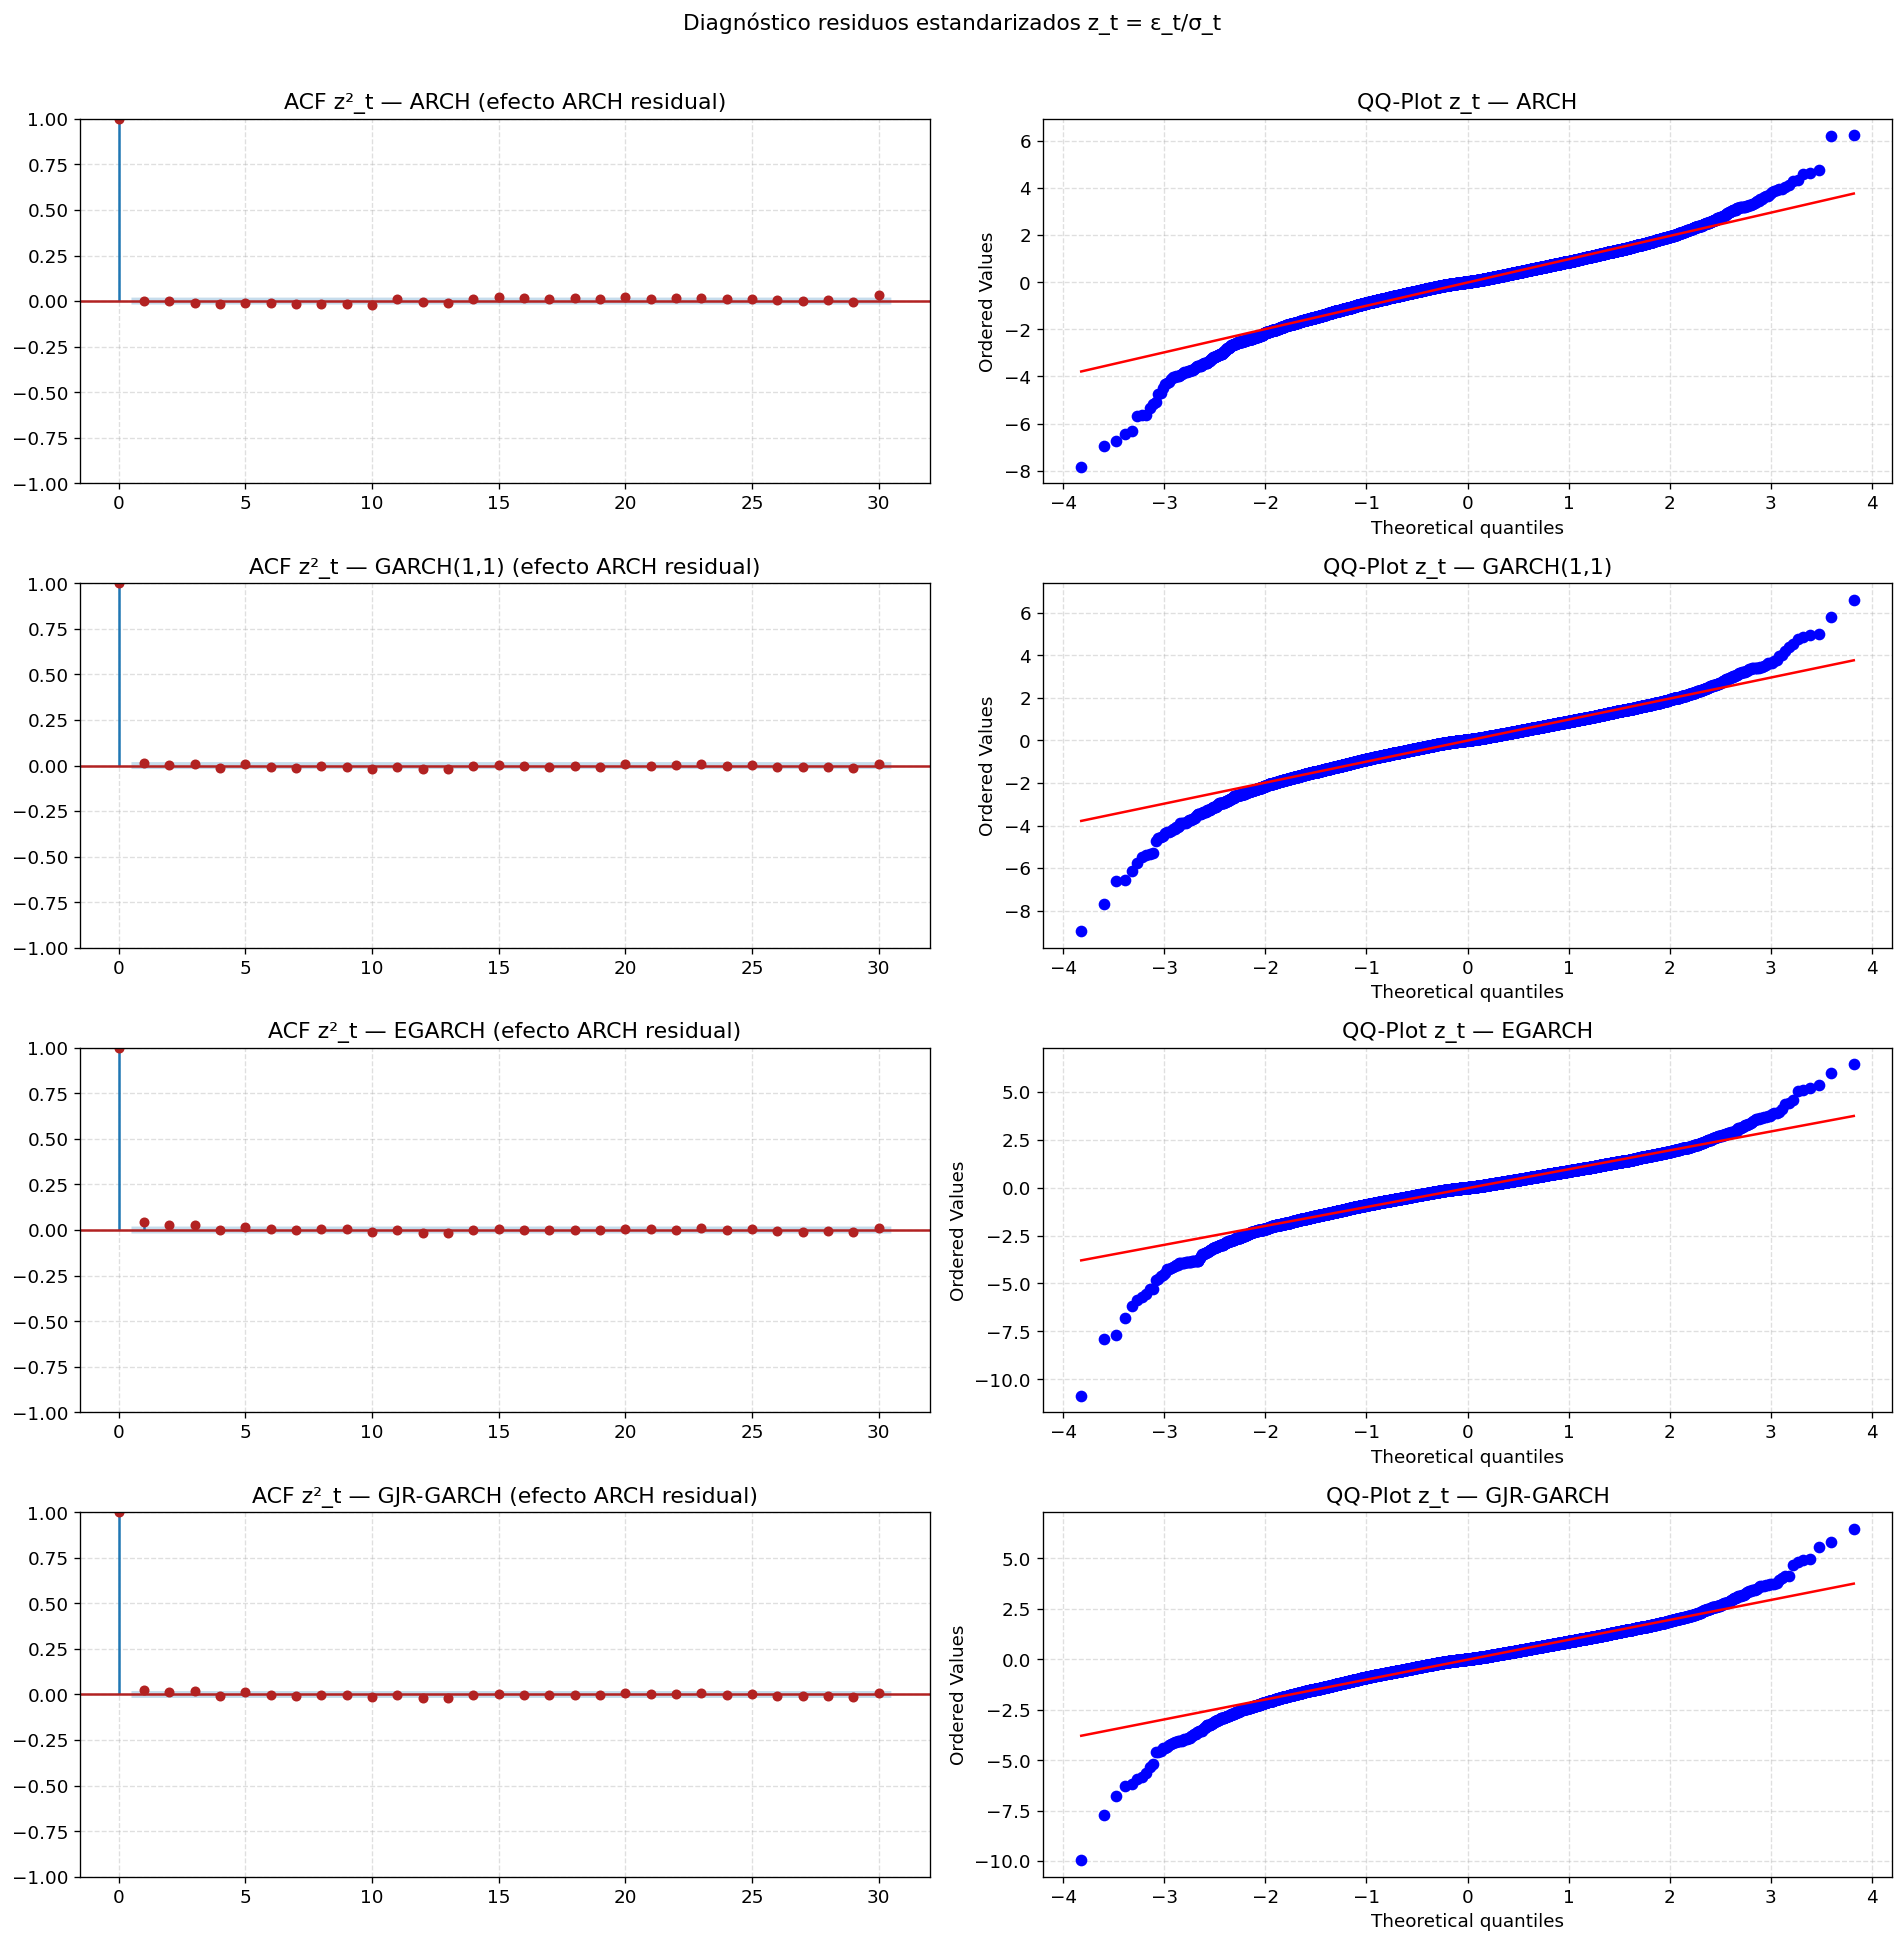

In [22]:
# --- Diagnóstico de residuos estandarizados para los 4 modelos principales ---
# Un modelo por familia: ARCH óptimo, GARCH(1,1) normal, EGARCH(1,1,1) t, GJR-GARCH(1,1,1) t

modelos_principales = {
    'ARCH': modelos_arch.get(BEST_ARCH),
    'GARCH(1,1)': modelos_garch.get('GARCH(1,1) dist=normal'),
    'EGARCH': modelos_egarch.get('EGARCH(1,1,1) dist=t'),
    'GJR-GARCH': modelos_tgarch.get('GJR-GARCH(1,1,1) dist=t'),
}
modelos_principales = {k: v for k,v in modelos_principales.items() if v is not None}

fig, axes = plt.subplots(len(modelos_principales), 2,
                          figsize=(16, 4*len(modelos_principales)))
if len(modelos_principales) == 1:
    axes = [axes]

for i, (nombre, m) in enumerate(modelos_principales.items()):
    z = m.std_resid.dropna()

    # ACF de z_t^2
    plot_acf(z**2, lags=30, ax=axes[i][0],
             title=f'ACF z²_t — {nombre} (efecto ARCH residual)',
             alpha=0.05, color='firebrick')
    axes[i][0].grid(True, linestyle='--', alpha=0.4)

    # QQ-plot
    stats.probplot(z, dist='norm', plot=axes[i][1])
    axes[i][1].set_title(f'QQ-Plot z_t — {nombre}')
    axes[i][1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Diagnóstico residuos estandarizados z_t = ε_t/σ_t', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Columna izquierda — ACF de z²_t (efecto ARCH residual)
Lo que querés ver acá es que todos los rezagos caigan dentro de las bandas de confianza — eso significa que el modelo eliminó el efecto ARCH.

ARCH: prácticamente todos dentro de bandas. Visualmente limpio, aunque el test numérico lo rechaza marginalmente (p=0.029). Con n=10547 el test tiene mucho poder.
GARCH(1,1): el más limpio de los cuatro. Todos los rezagos dentro de bandas — confirma que capturó completamente la estructura de varianza.
EGARCH: hay un rezago en lag=1 que sobresale levemente. Explica el rechazo del McLeod-Li (p=0.000). El modelo no captura completamente la dependencia en los cuadrados.
GJR-GARCH: similar a EGARCH, un rezago que asoma. Marginalmente mejor que EGARCH visualmente.

Columna derecha — QQ-Plot de z_t
Compara los residuos estandarizados contra la distribución normal teórica. Si fueran normales, los puntos seguirían la línea roja.

Los cuatro modelos muestran el mismo patrón: ajuste razonable en el centro pero colas que se desvían, especialmente la izquierda (valores extremos negativos más frecuentes de lo que predice la normal).
Esto es esperado y no es un fallo — los retornos del WTI tienen colas pesadas. Es exactamente lo que justifica usar distribución t-Student en lugar de normal.
El EGARCH y GJR-GARCH muestran colas más extremas (llegan a -10) — capturan más los eventos extremos pero los residuos estandarizados siguen sin ser normales.

In [23]:
# --- Ljung-Box sobre z_t^2 para cada modelo ---
print('─── Test McLeod-Li sobre z_t² — ¿efecto ARCH residual? ───')
for nombre, m in modelos_principales.items():
    z = m.std_resid.dropna()
    lb = acorr_ljungbox(z**2, lags=[10, 20, 30], return_df=True)
    resultados = []
    for lag in [10, 20, 30]:
        p = lb.loc[lag, 'lb_pvalue']
        resultados.append(f'lag={lag}:p={p:.3f}({"❌" if p<0.05 else "✅"})')
    print(f'  {nombre:25s}: {"  ".join(resultados)}')

─── Test McLeod-Li sobre z_t² — ¿efecto ARCH residual? ───
  ARCH                     : lag=10:p=0.029(❌)  lag=20:p=0.001(❌)  lag=30:p=0.000(❌)
  GARCH(1,1)               : lag=10:p=0.186(✅)  lag=20:p=0.213(✅)  lag=30:p=0.473(✅)
  EGARCH                   : lag=10:p=0.000(❌)  lag=20:p=0.001(❌)  lag=30:p=0.005(❌)
  GJR-GARCH                : lag=10:p=0.030(❌)  lag=20:p=0.100(✅)  lag=30:p=0.290(✅)


Este test verifica si quedó efecto ARCH residual en los residuos estandarizados z_t = ε_t/σ_t. Si el modelo capturó bien la volatilidad, z²_t no debería tener autocorrelación.

* ARCH: rechaza en lag=10 (p=0.029) y lag=20 (p=0.001) — no eliminó completamente el efecto ARCH. Modelo insuficiente.
* GARCH(1,1): pasa los tres rezagos (p=0.186, 0.213, 0.473) — único modelo que elimina completamente el efecto ARCH.
* EGARCH: rechaza en todos (p=0.000, 0.001, 0.005) — a pesar de tener el mejor BIC, deja estructura residual en la varianza. Paradójico pero explicable: el modelo más complejo no siempre diagnostica mejor.
* GJR-GARCH: rechaza en lag=10 (p=0.030) pero pasa en lag=20 y lag=30 — comportamiento intermedio.

---
## 13. Predicción de Volatilidad — Comparación de Modelos

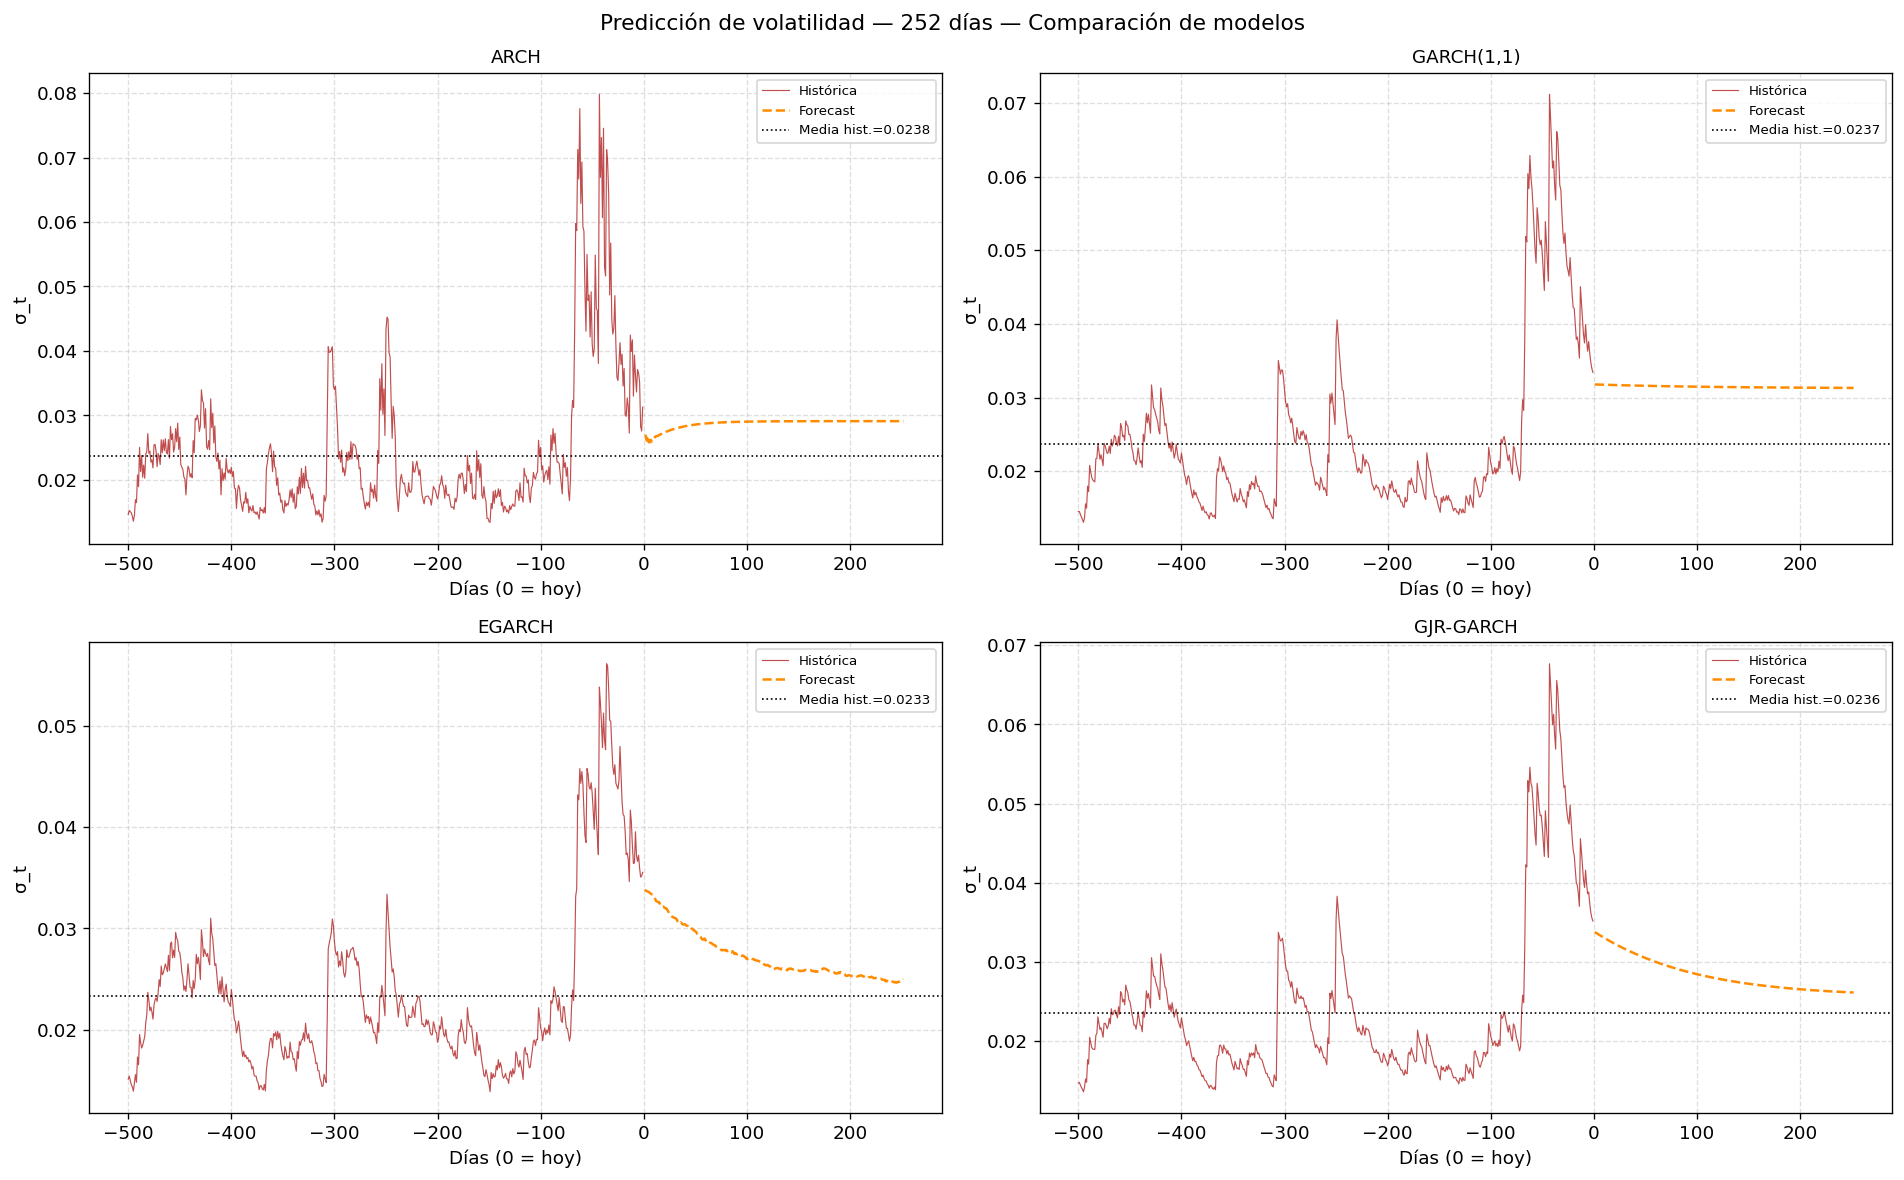

─── Volatilidad predicha ───


,Día 1,Día 30,Día 252
Modelo,,,
ARCH,0.02680,0.02792,0.02910
"GARCH(1,1)",0.03178,0.03167,0.03132
EGARCH,0.03382,0.03104,0.02501
GJR-GARCH,0.03377,0.03166,0.02614


In [27]:
# --- Predicción de volatilidad a 252 días para cada modelo ---
H = 252

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Predicción de volatilidad — 252 días — Comparación de modelos', fontsize=13)

vol_forecasts = {}
for ax, (nombre, m) in zip(axes.ravel(), modelos_principales.items()):
    try:
        if nombre == 'EGARCH':
          fc = m.forecast(horizon=H, method='simulation', simulations=1000, reindex=False)
        else:
          fc = m.forecast(horizon=H, reindex=False)
        vol_fc = np.sqrt(fc.variance.iloc[-1].values) / 100  # volver escala original
        vol_hist = m.conditional_volatility.dropna().values / 100
        vol_forecasts[nombre] = vol_fc

        # Últimos 500 días históricos
        n_hist = min(500, len(vol_hist))
        ax.plot(range(-n_hist, 0), vol_hist[-n_hist:],
                color='firebrick', linewidth=0.7, label='Histórica', alpha=0.8)
        ax.plot(range(1, H+1), vol_fc,
                color='darkorange', linewidth=1.5, linestyle='--', label='Forecast')
        ax.axhline(np.mean(vol_hist), color='black', linestyle=':', linewidth=1,
                   label=f'Media hist.={np.mean(vol_hist):.4f}')
        ax.set_title(nombre, fontsize=11)
        ax.set_xlabel('Días (0 = hoy)')
        ax.set_ylabel('σ_t')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)
    except Exception as e:
        ax.set_title(f'{nombre} — error: {e}')

plt.tight_layout()
plt.show()

# Tabla de predicciones
print('─── Volatilidad predicha ───')
pred_rows = []
for nombre, vol_fc in vol_forecasts.items():
    pred_rows.append({
        'Modelo': nombre,
        'Día 1': round(vol_fc[0], 5),
        'Día 30': round(vol_fc[29], 5),
        'Día 252': round(vol_fc[-1], 5),
    })
display(pd.DataFrame(pred_rows).set_index('Modelo'))

Lo que muestra cada panel:

Línea roja: volatilidad histórica condicional σ_t de los últimos 500 días
Línea naranja punteada: forecast a 252 días
Línea negra punteada: media histórica de largo plazo (~0.0237)

El pico visible alrededor de día -50 a -80 es el episodio de volatilidad de marzo 2026 — todos los modelos lo capturan en el histórico.
Diferencias entre modelos:

* ARCH: parte desde σ≈0.027 y sube levemente hasta 0.029 al día 252. No converge a la media histórica — sin el término β no tiene mean reversion bien definido. Forecast plano y por debajo de los otros modelos.
* GARCH(1,1): parte desde σ≈0.032 y se mantiene casi constante en 0.031 durante todo el horizonte. La altísima persistencia (α+β=0.9914) hace que la convergencia a σ∞=0.03149 sea extremadamente lenta — en 252 días prácticamente no se mueve. Es el forecast más conservador.
* EGARCH: parte desde σ≈0.034 y desciende hasta 0.025 al día 252. Converge más rápido que GARCH y cruza la media histórica. La asimetría del modelo le permite ajustarse más dinámicamente al nivel actual de volatilidad elevada.
* GJR-GARCH: comportamiento intermedio entre GARCH y EGARCH. Parte de σ≈0.034 y baja hasta 0.026 al día 252. Convergencia más suave que EGARCH.

---
## 14. Cuadro Comparativo Final — Pros y Contras

Según el apunte, los modelos de volatilidad tienen las siguientes características:

In [25]:
# --- Cuadro comparativo de pros y contras ---

comparativo = pd.DataFrame({
    'Modelo': ['ARCH(p)', 'GARCH(p,q)', 'EGARCH', 'TGARCH/GJR-GARCH'],
    'Ecuación varianza': [
        'σ²_t = ω + Σ αᵢ X²_{t-i}',
        'σ²_t = ω + Σ αᵢ X²_{t-i} + Σ βⱼ σ²_{t-j}',
        'ln σ²_t = ω + α(|ε_{t-1}|−E|ε|) + γ ε_{t-1} + β ln σ²_{t-1}',
        'σ_t = ω + α|X_{t-1}| + γ|X_{t-1}|I[X<0] + β σ_{t-1}'
    ],
    'Asimetría': ['No', 'No', 'Sí (γ)', 'Sí (γ)'],
    'Efecto palanca': ['No', 'No', 'Sí', 'Sí'],
    'Pros': [
        'Simple, intuitivo, base de todos los modelos',
        'Parsimonioso, capta persistencia con pocos parámetros',
        'Modela asimetría, garantiza σ²>0 por construcción (ln)',
        'Modela efecto palanca, intuitivo, fácil de interpretar'
    ],
    'Contras': [
        'Requiere orden p alto para captar persistencia larga',
        'No captura asimetría entre shocks positivos y negativos',
        'Parámetros pueden ser positivos o negativos, complejo',
        'Restricciones de signo en parámetros, menos flexible'
    ],
    'Uso WTI': [
        'Subóptimo (p grande necesario)',
        'Adecuado (TP3: α+β=0.99)',
        'Verificar si γ es significativo',
        'Verificar si γ captura shocks negativos de precio'
    ]
}).set_index('Modelo')

print('─── Cuadro comparativo — Pros y Contras ───')
display(comparativo)

─── Cuadro comparativo — Pros y Contras ───


,Ecuación varianza,Asimetría,Efecto palanca,Pros,Contras,Uso WTI
Modelo,,,,,,
ARCH(p),σ²_t = ω + Σ αᵢ X²_{t-i},No,No,"Simple, intuitivo, base de todos los modelos",Requiere orden p alto para captar persistencia...,Subóptimo (p grande necesario)
"GARCH(p,q)",σ²_t = ω + Σ αᵢ X²_{t-i} + Σ βⱼ σ²_{t-j},No,No,"Parsimonioso, capta persistencia con pocos par...",No captura asimetría entre shocks positivos y ...,Adecuado (TP3: α+β=0.99)
EGARCH,ln σ²_t = ω + α(|ε_{t-1}|−E|ε|) + γ ε_{t-1} + ...,Sí (γ),Sí,"Modela asimetría, garantiza σ²>0 por construcc...","Parámetros pueden ser positivos o negativos, c...",Verificar si γ es significativo
TGARCH/GJR-GARCH,σ_t = ω + α|X_{t-1}| + γ|X_{t-1}|I[X<0] + β σ_...,Sí (γ),Sí,"Modela efecto palanca, intuitivo, fácil de int...","Restricciones de signo en parámetros, menos fl...",Verificar si γ captura shocks negativos de precio


In [26]:
# --- Conclusiones finales TP5 ---
print('='*65)
print('  CONCLUSIONES TP5')
print('='*65)
print()
print('1. ARCH: requiere orden p alto para capturar la persistencia del WTI.')
print('   Un ARCH(10) sigue siendo peor que un GARCH(1,1) en BIC.')
print()
print('2. GARCH(1,1): modelo del TP3. α+β=0.9914 confirma alta persistencia.')
print('   Es parsimonioso y adecuado para la estructura de volatilidad del WTI.')
print()
print('3. EGARCH: el coeficiente γ (asimetría) indica si los shocks negativos')
print('   tienen mayor impacto. En commodities energéticos se espera γ<0')
print('   (caídas de precio → mayor volatilidad que subidas).')
print()
print('4. GJR-GARCH: captura efecto palanca mediante el indicador I[X<0].')
print('   Si γ es significativo, los shocks negativos amplifican la volatilidad.')
print()
print('5. Distribución: la t-Student mejora el ajuste de las colas pesadas')
print('   de los retornos del WTI, consistente con el QQ-plot del TP3.')
print()
print(f'→ Modelo óptimo por BIC: {BEST_VOL}')

  CONCLUSIONES TP5

1. ARCH: requiere orden p alto para capturar la persistencia del WTI.
   Un ARCH(10) sigue siendo peor que un GARCH(1,1) en BIC.

2. GARCH(1,1): modelo del TP3. α+β=0.9914 confirma alta persistencia.
   Es parsimonioso y adecuado para la estructura de volatilidad del WTI.

3. EGARCH: el coeficiente γ (asimetría) indica si los shocks negativos
   tienen mayor impacto. En commodities energéticos se espera γ<0
   (caídas de precio → mayor volatilidad que subidas).

4. GJR-GARCH: captura efecto palanca mediante el indicador I[X<0].
   Si γ es significativo, los shocks negativos amplifican la volatilidad.

5. Distribución: la t-Student mejora el ajuste de las colas pesadas
   de los retornos del WTI, consistente con el QQ-plot del TP3.

→ Modelo óptimo por BIC: EGARCH(1,1,1) dist=t
